# Retail Sales Forecasting & Intelligence Dashboard

**Goal:** predict how many units a specific product will sell in a specific store over the next **28 days**.

Data: the **M5 / Walmart** dataset — 3,049 products x 10 stores x 3 states, daily unit sales from
2011-01-29 to 2016-05-22.

| file | what it is |
|---|---|
| `sales_train_evaluation.csv` | one row per (item, store) series, one column per day (`d_1` ... `d_1941`) |
| `calendar.csv` | one row per day: date, weekday, month, year, holidays/events, SNAP flags |
| `sell_prices.csv` | weekly selling price per (store, item) |
| `sample_submission.csv` | Kaggle submission template (not used here) |

**Notebook roadmap**

1. Load & inspect the raw files
2. Reshape to a tidy long table + build the weekly price table
3. **Part 1 — Exploratory Data Analysis** (trends, seasonality, products, stores, prices)
4. **Part 2 — Feature engineering** (calendar, lag, rolling, price features)
5. **Part 3 — Time-series train / validation / test split**
6. **Part 4 — Baselines** (naive, seasonal naive)
7. **Part 5 — ML models** (Linear Regression, Random Forest, XGBoost, LightGBM)
8. **Part 6 — Evaluation, explanation and packaging** (rolling-origin CV, WRMSSE, error analysis,
   Optuna tuning, direct vs recursive forecasting, feature importance and SHAP, MLflow tracking,
   and the artifacts the API serves)

## 0. Environment

Run once, then restart the kernel. Skip the whole section if the packages are already installed.

The notebook needs numpy, pandas, matplotlib, seaborn, scikit-learn, xgboost, lightgbm, optuna,
shap, mlflow, pyarrow and joblib. They are pinned in `requirements.txt`, so install them once, into a
virtual environment, before starting the kernel:

```bash
python -m venv .venv
.venv/Scripts/activate          # Linux/macOS: source .venv/bin/activate
pip install -r requirements.txt
```

Installing from inside the notebook is deliberately avoided: `%pip install` mutates the environment
that is already running, which makes "run all cells" behave differently on a fresh machine than on
one where a cell was run twice.


## 1. Load the raw data

Two things worth knowing before we read anything.

**Which sales file?** `sales_train_validation.csv` stops at `d_1913`; `sales_train_evaluation.csv` is
the same data plus 28 more days (`d_1941`). We use the **evaluation** file, because it lets us carve
out a 28-day validation window *and* a 28-day test window while keeping the original M5 horizon.

**Dtypes matter here.** The wide sales table is 30,490 x 1,941. With pandas' default `int64` that is
~470 MB before we have done anything. The largest single-day sale in the file is 763, so `int16` is
plenty and costs ~120 MB instead. The id columns repeat heavily, so `category` beats strings by an
order of magnitude. This is not premature optimisation — the long table we build in section 2 has
59 million rows, and the dtype choice decides whether it fits in RAM.

In [20]:
import gc
import numpy as np
import pandas as pd

DATA_DIR = "."   # the csv files live next to this notebook

_header  = pd.read_csv(f"{DATA_DIR}/sales_train_evaluation.csv", nrows=0)
DAY_COLS = [c for c in _header.columns if c.startswith("d_")]
ID_COLS  = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]

dtypes = {c: "int16" for c in DAY_COLS}
dtypes.update({c: "category" for c in ID_COLS})

sales = pd.read_csv(f"{DATA_DIR}/sales_train_evaluation.csv",
                    usecols=["id"] + ID_COLS + DAY_COLS, dtype=dtypes)

calendar = pd.read_csv(f"{DATA_DIR}/calendar.csv", parse_dates=["date"])

prices = pd.read_csv(f"{DATA_DIR}/sell_prices.csv",
                     dtype={"store_id": "category", "item_id": "category",
                            "wm_yr_wk": "int32", "sell_price": "float32"})

print(f"sales     {sales.shape[0]:>7,} rows x {sales.shape[1]:>5,} cols "
      f"({sales.memory_usage(deep=True).sum()/1e6:,.0f} MB)")
print(f"calendar  {calendar.shape[0]:>7,} rows x {calendar.shape[1]:>5,} cols")
print(f"prices    {prices.shape[0]:>7,} rows x {prices.shape[1]:>5,} cols")
print(f"days in sales file: {len(DAY_COLS):,}")

sales      30,490 rows x 1,947 cols (121 MB)
calendar    1,969 rows x    14 cols
prices    6,841,121 rows x     4 cols
days in sales file: 1,941


In [21]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [22]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: category(5), int16(1941), str(1)
memory usage: 113.4 MB


In [23]:
sales.shape

(30490, 1947)

### Missing values

The wide sales table has no missing values by construction — every (series, day) cell holds a count,
and a day with no sale is a genuine `0`, not a gap. The nulls that *do* exist live in the other two
files, and both are meaningful rather than dirty:

* `calendar.event_name_1 / event_type_1` — null means "no holiday that day" (1,807 of 1,969 days).
* `sell_prices` — a (store, item, week) row is **absent** when the store was not selling that product
  that week. After the join those become null prices, and they are the correct signal for
  "this product was not stocked here yet".

In [24]:
sales.isnull().sum().sum()   # total nulls across the whole wide table

np.int64(0)

In [25]:
# Calendar
display(calendar.head())
calendar.info()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[us]
 1   wm_yr_wk      1969 non-null   int64         
 2   weekday       1969 non-null   str           
 3   wday          1969 non-null   int64         
 4   month         1969 non-null   int64         
 5   year          1969 non-null   int64         
 6   d             1969 non-null   str           
 7   event_name_1  162 non-null    str           
 8   event_type_1  162 non-null    str           
 9   event_name_2  5 non-null      str           
 10  event_type_2  5 non-null      str           
 11  snap_CA       1969 non-null   int64         
 12  snap_TX       1969 non-null   int64         
 13  snap_WI       1969 non-null   int64         
dtypes: datetime64[us](1), int64(7), str(6)
memory usage: 215.5 KB


In [26]:
print(calendar["event_type_1"].value_counts(dropna=False).to_string())
print()
print("distinct named events:", calendar["event_name_1"].nunique())

event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18

distinct named events: 30


In [ ]:
# Prices
display(prices.head())
prices.info()

### Size of the hierarchy

The data is a product hierarchy (`state -> store`, `category -> department -> item`). The cardinalities
tell us how many individual time series we are actually forecasting.

In [27]:
print(sales[ID_COLS].nunique().to_string())
print()
print(f"series to forecast: {len(sales):,}  (= 3,049 items x 10 stores)")
print(f"observations:       {len(sales) * len(DAY_COLS):,}")

item_id     3049
dept_id        7
cat_id         3
store_id      10
state_id       3

series to forecast: 30,490  (= 3,049 items x 10 stores)
observations:       59,181,090


## 2. Reshape: wide -> long

Every analysis and every model below wants **one row per (item, store, day)**. The obvious way there
is `sales.melt(...)`.

**On this dataset that fails on an 8 GB machine.** `melt` materialises the `d_1 ... d_1941` column
*names* as a 59-million-element object array before it can compress anything, which asks the allocator
for a contiguous ~450 MB block on top of everything else and raises `MemoryError`.

So we do the reshape in NumPy instead, which lets us pick the dtype of every output column up front:

* `.to_numpy().ravel(order="C")` flattens the matrix **row-major** — all 1,941 days of series 1, then
  all 1,941 days of series 2, ... — so the id columns are just `np.repeat` and the day column is just
  `np.tile`.
* the id columns are rebuilt with `pd.Categorical.from_codes`, which repeats the *integer codes*
  (1–2 bytes each) instead of the strings.
* the day is stored as `d_num` (an `int16` 1...1941) rather than the string `"d_1"`. Real dates get
  attached later, on the small aggregated tables, where a `datetime64` column costs kilobytes instead
  of half a gigabyte.

Same 59M-row table, ~600 MB.

In [28]:
n_series, n_days = len(sales), len(DAY_COLS)

sales_matrix = sales[DAY_COLS].to_numpy(dtype=np.int16)      # (30490, 1941)

long_cols = {}
for c in ID_COLS:
    col = sales[c]
    long_cols[c] = pd.Categorical.from_codes(
        np.repeat(col.cat.codes.to_numpy(), n_days),         # repeat codes, not strings
        categories=col.cat.categories,
    )
long_cols["d_num"] = np.tile(np.arange(1, n_days + 1, dtype="int16"), n_series)
long_cols["sales"] = sales_matrix.ravel(order="C")

df = pd.DataFrame(long_cols)
del sales_matrix, long_cols
gc.collect()

# sanity check: reshaping must not lose or invent a single unit
assert df["sales"].sum() == sales[DAY_COLS].to_numpy(dtype="int64").sum()

print(f"{len(df):,} rows   {df.memory_usage(deep=True).sum()/1e6:,.0f} MB")
df.head()

59,181,090 rows   592 MB


,item_id,dept_id,cat_id,store_id,state_id,d_num,sales
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0
1,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,2,0
2,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,3,0
3,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,4,0
4,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,5,0


### Calendar lookup table

`calendar.csv` runs 28 days past the sales file (it covers the Kaggle forecast window), so we clip it
to the days we actually have. `d_num` is a clean integer key into it.

In [29]:
calendar["d_num"] = calendar["d"].str.slice(2).astype("int32")
calendar = calendar.sort_values("d_num").reset_index(drop=True)

cal = calendar[calendar["d_num"] <= n_days].reset_index(drop=True).copy()
cal["is_weekend"]   = cal["wday"].isin([1, 2])          # wday 1 = Saturday, 2 = Sunday
cal["day_of_month"] = cal["date"].dt.day
cal["quarter"]      = cal["date"].dt.quarter
cal["week"]         = cal["date"].dt.isocalendar().week.astype("int16")
cal["day_of_year"]  = cal["date"].dt.dayofyear

WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
MONTH_NAMES   = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                 "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print(f"{len(cal):,} days   {cal['date'].min().date()} -> {cal['date'].max().date()}")
cal[["d_num", "date", "weekday", "wday", "month", "year", "wm_yr_wk",
     "event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"]].head()

1,941 days   2011-01-29 -> 2016-05-22


,d_num,date,weekday,wday,month,year,wm_yr_wk,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI
0,1,2011-01-29,Saturday,1,1,2011,11101,NaN,NaN,0,0,0
1,2,2011-01-30,Sunday,2,1,2011,11101,NaN,NaN,0,0,0
2,3,2011-01-31,Monday,3,1,2011,11101,NaN,NaN,0,0,0
3,4,2011-02-01,Tuesday,4,2,2011,11101,NaN,NaN,1,1,0
4,5,2011-02-02,Wednesday,5,2,2011,11101,NaN,NaN,1,0,1


Now attach the calendar columns we need at row level. Rather than a 59M-row `merge` (which builds a
hash table and a full copy), we index a NumPy array by position: `d_num` is 1-based and `cal` is
sorted by `d_num`, so `array[d_num - 1]` **is** the join — one pass, no intermediate.

In [30]:
day_index = df["d_num"].to_numpy() - 1        # d_num is 1-based, arrays are 0-based

df["wday"]  = cal["wday"].to_numpy(dtype="int8")[day_index]
df["month"] = cal["month"].to_numpy(dtype="int8")[day_index]
df["year"]  = cal["year"].to_numpy(dtype="int16")[day_index]

print(f"{df.memory_usage(deep=True).sum()/1e6:,.0f} MB")
df.head()

829 MB


,item_id,dept_id,cat_id,store_id,state_id,d_num,sales,wday,month,year
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,1,1,2011
1,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,2,0,2,1,2011
2,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,3,0,3,1,2011
3,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,4,0,4,2,2011
4,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,5,0,5,2,2011


### Weekly item x store table (for prices and revenue)

`sell_prices.csv` is **weekly**, so joining it onto 59M daily rows would be wasteful. Instead we
aggregate sales to the grain the prices live at — (item, store, retail week) — giving an 8.5M-row
table that answers every price and revenue question cheaply.

`np.add.reduceat` does the aggregation in one pass: retail weeks are contiguous blocks of days, so all
it needs is the index where each block starts.

In [31]:
week_of_day = cal["wm_yr_wk"].to_numpy()
week_starts = np.flatnonzero(np.r_[True, np.diff(week_of_day) != 0])   # first day of each week
week_ids    = week_of_day[week_starts]

matrix_i32    = sales[DAY_COLS].to_numpy(dtype=np.int32)
weekly_matrix = np.add.reduceat(matrix_i32, week_starts, axis=1)       # (30490, 278)
del matrix_i32
gc.collect()

n_weeks = weekly_matrix.shape[1]

def _rep(col):
    s = sales[col]
    return pd.Categorical.from_codes(np.repeat(s.cat.codes.to_numpy(), n_weeks),
                                     categories=s.cat.categories)

weekly = pd.DataFrame({
    "item_id":  _rep("item_id"),
    "dept_id":  _rep("dept_id"),
    "cat_id":   _rep("cat_id"),
    "store_id": _rep("store_id"),
    "state_id": _rep("state_id"),
    "wm_yr_wk": np.tile(week_ids, n_series).astype("int32"),
    "units":    weekly_matrix.ravel(order="C"),
})
del weekly_matrix
gc.collect()

weekly = weekly.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
weekly["revenue"] = weekly["units"] * weekly["sell_price"]

print(f"{len(weekly):,} rows   {weekly.memory_usage(deep=True).sum()/1e6:,.0f} MB")
print(f"weeks with no price on file: {weekly['sell_price'].isna().mean():.1%}"
      "   (product not stocked in that store that week)")
weekly.head()

8,476,220 rows   255 MB
weeks with no price on file: 20.7%   (product not stocked in that store that week)


,item_id,dept_id,cat_id,store_id,state_id,wm_yr_wk,units,sell_price,revenue
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,11101,0,NaN,NaN
1,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,11102,0,NaN,NaN
2,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,11103,0,NaN,NaN
3,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,11104,0,NaN,NaN
4,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,11105,0,NaN,NaN


Those no-price weeks are a real property of the dataset, not a data-quality problem: products are
introduced over time, and before the introduction week the store has no price and no sales. They get
dropped before modelling in Part 2 — training a model to predict zero for a product that did not exist
teaches it nothing useful.

---

# Part 1 — Exploratory Data Analysis

This is the analytics half of the project and the first section of the dashboard. Everything below
answers a specific question:

| Theme | Questions |
|---|---|
| **Sales trends** | How are sales changing over time? |
| **Seasonality** | Do sales rise at weekends? Do they rise at Christmas? Which months are strongest? |
| **Products** | Which products sell the most? Which categories generate the most revenue? |
| **Stores** | Which store performs best? Which state performs best? |
| **Prices** | Does price affect sales? Do promotions increase sales? |

Charts: daily / weekly / monthly sales, sales by category, by store, by weekday, sales vs price, and
sales during events.

## 1.0 Plotting setup

One palette, used consistently for the whole notebook. The categorical hues are assigned in a fixed
order and never cycled, so a colour always means the same entity. Bars that show a single measure get
a single colour — bar length already encodes magnitude, so shading by value would burn the colour
channel on information the chart already shows.

In [32]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# fixed categorical slots — assigned in order, never cycled
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = SERIES
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

SURFACE, INK, INK2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#b4b2a9", "#e6e5e0"

mpl.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelsize": 10, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK2,
    "lines.linewidth": 2.0, "lines.markersize": 5,
    "font.size": 10, "text.color": INK,
})

THOUSANDS = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")

def finish(ax, title=None, subtitle=None, xlabel=None, ylabel=None,
           yfmt=True, xgrid=False, legend=False):
    """Apply the house style to an axes and return it."""
    if title:
        ax.set_title(title if not subtitle else f"{title}\n", loc="left")
        if subtitle:
            ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9.5,
                    color=MUTED, va="bottom")
    ax.set_xlabel(xlabel or "", labelpad=8)
    ax.set_ylabel(ylabel or "", labelpad=8)
    ax.grid(axis="x", visible=xgrid)
    ax.grid(axis="y", visible=not xgrid)
    ax.set_axisbelow(True)
    if yfmt:
        (ax.xaxis if xgrid else ax.yaxis).set_major_formatter(THOUSANDS)
    if legend:
        ax.legend(loc="upper left", ncols=legend if isinstance(legend, int) else 1)
    return ax

def bar_labels(ax, bars, fmt="{:,.0f}", pad=3):
    """Direct-label a small set of bars (never on a chart with many marks)."""
    ax.bar_label(bars, fmt=lambda v: fmt.format(v), padding=pad,
                 fontsize=9, color=INK2)

print("plot style ready")

plot style ready


## 1.1 Analysis tables

Four small aggregates carry almost the whole EDA. Building them once keeps every chart below a
sub-second operation on a table of a few thousand rows, instead of a repeated pass over 59 million.

In [33]:
# daily chain-wide totals
daily = df.groupby("d_num", observed=True)["sales"].sum().reset_index(name="units")
daily = daily.merge(
    cal[["d_num", "date", "weekday", "wday", "is_weekend", "month", "year", "week",
         "quarter", "day_of_month", "day_of_year", "wm_yr_wk",
         "event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"]],
    on="d_num", how="left")
daily["ma_28"]     = daily["units"].rolling(28, center=True).mean()
daily["is_closed"] = daily["units"] < 1_000          # Christmas Day: stores shut

# daily totals per category and per store
daily_cat   = (df.groupby(["cat_id", "d_num"], observed=True)["sales"].sum()
                 .reset_index(name="units").merge(cal[["d_num", "date"]], on="d_num"))
daily_store = (df.groupby(["store_id", "d_num"], observed=True)["sales"].sum()
                 .reset_index(name="units")
                 .merge(cal[["d_num", "date", "year", "month"]], on="d_num"))
daily_state = (df.groupby(["state_id", "d_num"], observed=True)["sales"].sum()
                 .reset_index(name="units").merge(cal[["d_num", "date"]], on="d_num"))

print(f"daily {daily.shape} | daily_cat {daily_cat.shape} | "
      f"daily_store {daily_store.shape} | daily_state {daily_state.shape}")
daily.head(3)

daily (1941, 20) | daily_cat (5823, 4) | daily_store (19410, 6) | daily_state (5823, 4)


,d_num,units,date,weekday,wday,is_weekend,month,year,week,quarter,day_of_month,day_of_year,wm_yr_wk,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,ma_28,is_closed
0,1,32631,2011-01-29,Saturday,1,True,1,2011,4,1,29,29,11101,NaN,NaN,0,0,0,NaN,False
1,2,31749,2011-01-30,Sunday,2,True,1,2011,4,1,30,30,11101,NaN,NaN,0,0,0,NaN,False
2,3,23783,2011-01-31,Monday,3,False,1,2011,5,1,31,31,11101,NaN,NaN,0,0,0,NaN,False


## 1.2 Sales trends — how are sales changing over time?

### Daily sales

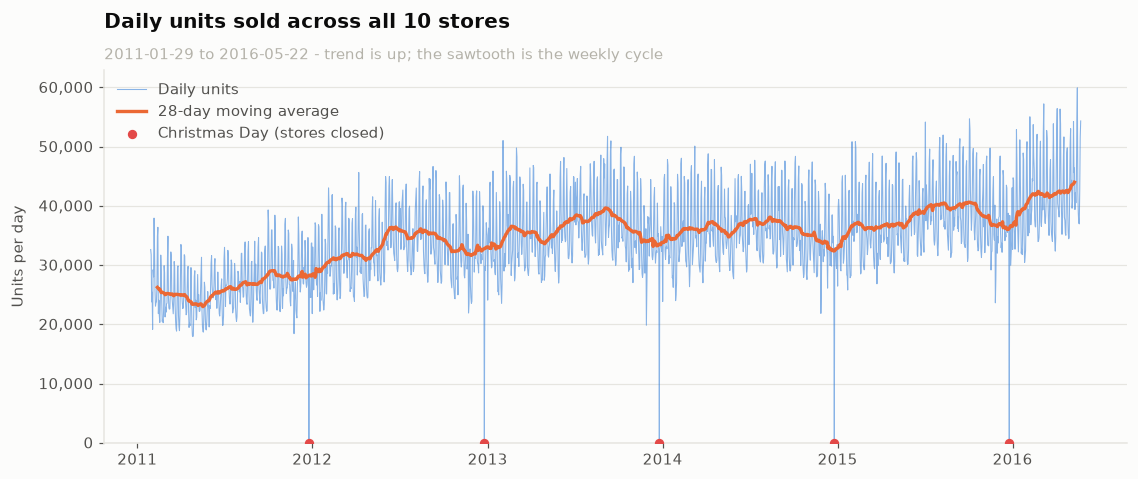

average day in 2012: 32,956 units
average day in 2015: 37,810 units   ->  +14.7% over 3 years


In [34]:
fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(daily["date"], daily["units"], lw=0.7, color=BLUE, alpha=0.55, label="Daily units")
ax.plot(daily["date"], daily["ma_28"], lw=2.2, color=ORANGE, label="28-day moving average")

closed = daily[daily["is_closed"]]
ax.scatter(closed["date"], closed["units"], s=26, color=RED, zorder=5,
           label="Christmas Day (stores closed)")

finish(ax, "Daily units sold across all 10 stores",
       "2011-01-29 to 2016-05-22 - trend is up; the sawtooth is the weekly cycle",
       ylabel="Units per day", legend=True)
ax.set_ylim(0, None)
plt.show()

first_yr = daily[daily["year"] == 2012]["units"].mean()
last_yr  = daily[daily["year"] == 2015]["units"].mean()
print(f"average day in 2012: {first_yr:,.0f} units")
print(f"average day in 2015: {last_yr:,.0f} units   ->  {last_yr/first_yr - 1:+.1%} over 3 years")

Three things are immediately visible and shape every modelling decision later:

* **A clear upward trend**, but a decelerating one — the steep climb is 2011→2013, after which growth
  flattens.
* **A dense sawtooth** — that is the weekly cycle, and it is by far the strongest signal in the data.
* **Five single-day collapses to near-zero.** Those are 25 December each year: the stores close. The
  handful of units recorded are data artefacts. Any model must be told about them rather than left to
  average them into December.

### Weekly sales

Aggregating to whole retail weeks removes the day-of-week sawtooth and leaves the trend.

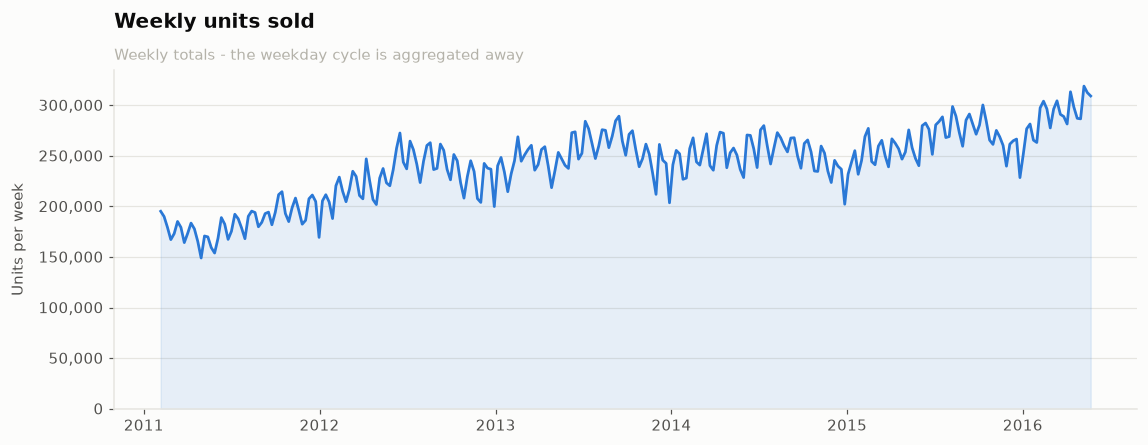

In [35]:
weekly_total = daily.set_index("date")["units"].resample("W-SAT").sum()
weekly_total = weekly_total.iloc[1:-1]        # drop the partial first and last weeks

fig, ax = plt.subplots(figsize=(12, 4.0))
ax.plot(weekly_total.index, weekly_total.values, lw=1.8, color=BLUE)
ax.fill_between(weekly_total.index, weekly_total.values, color=BLUE, alpha=0.10)
finish(ax, "Weekly units sold", "Weekly totals - the weekday cycle is aggregated away",
       ylabel="Units per week")
ax.set_ylim(0, None)
plt.show()

### Monthly sales

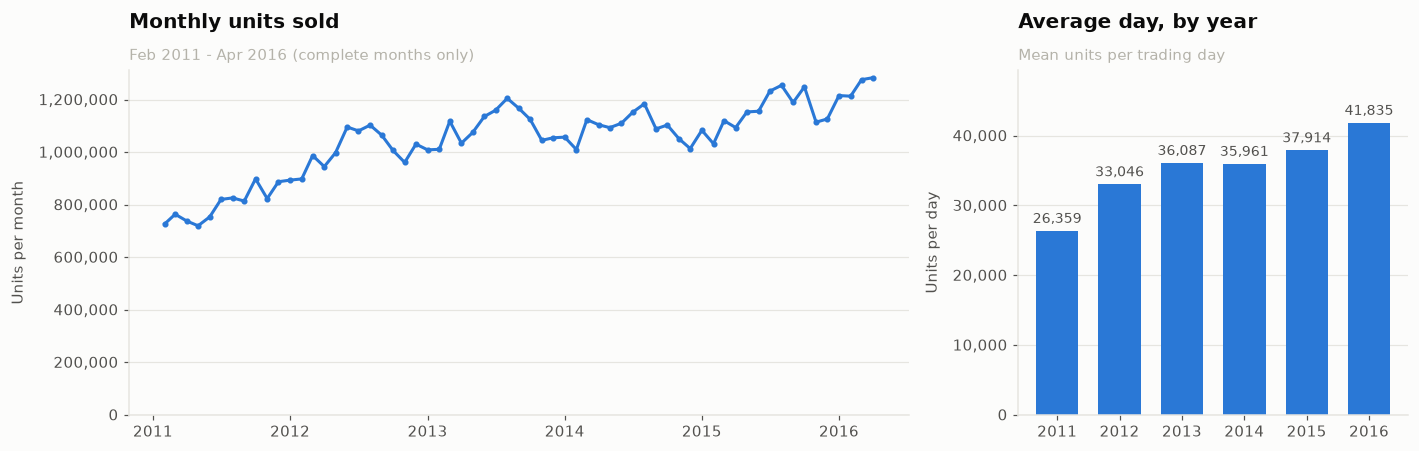

year
2011    26359.0
2012    33046.0
2013    36087.0
2014    35961.0
2015    37914.0
2016    41835.0


In [36]:
monthly_total = daily.set_index("date")["units"].resample("MS").sum()
monthly_total = monthly_total.iloc[1:-1]      # Jan 2011 and May 2016 are partial months

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [2, 1]})

axes[0].plot(monthly_total.index, monthly_total.values, lw=2.0, color=BLUE, marker="o", ms=3)
finish(axes[0], "Monthly units sold", "Feb 2011 - Apr 2016 (complete months only)",
       ylabel="Units per month")
axes[0].set_ylim(0, None)

# year-on-year: mean units per *open* day, so partial years compare fairly
yearly = daily[~daily["is_closed"]].groupby("year")["units"].mean()
bars = axes[1].bar(yearly.index.astype(str), yearly.values, color=BLUE, width=0.68)
bar_labels(axes[1], bars)
finish(axes[1], "Average day, by year", "Mean units per trading day", ylabel="Units per day")
axes[1].set_ylim(0, yearly.max() * 1.18)

plt.tight_layout()
plt.show()

print(yearly.round(0).to_string())

Comparing *mean units per trading day* rather than yearly totals is what makes 2011 (11 months) and
2016 (under 5 months) comparable at all. On that basis: **+25.4% in 2012, +9.2% in 2013, −0.4% in
2014, +5.4% in 2015, +10.3% into 2016**. Strong early growth, a flat year, then a renewed climb — not
one clean trend, which is why the models get `year` and `day_of_year` rather than a fitted slope.

## 1.3 Seasonality

### Do sales increase at weekends?

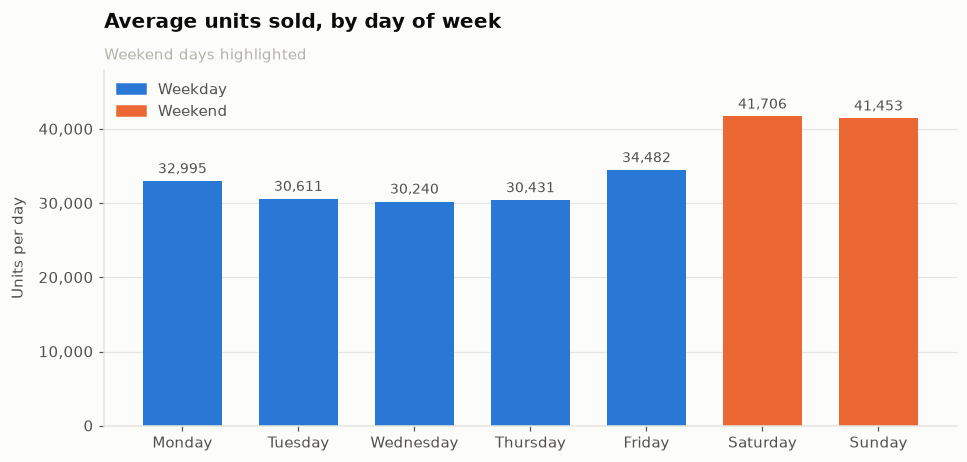

weekday average: 31,753 units
weekend average: 41,580 units
weekend lift:    +30.9%


In [37]:
by_weekday = (daily[~daily["is_closed"]].groupby("weekday", observed=True)["units"].mean()
                   .reindex(WEEKDAY_ORDER))

is_we   = [d in ("Saturday", "Sunday") for d in by_weekday.index]
colours = [ORANGE if w else BLUE for w in is_we]

fig, ax = plt.subplots(figsize=(10, 4.2))
bars = ax.bar(by_weekday.index, by_weekday.values, color=colours, width=0.68)
bar_labels(ax, bars)
finish(ax, "Average units sold, by day of week",
       "Weekend days highlighted", ylabel="Units per day")
ax.set_ylim(0, by_weekday.max() * 1.15)
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)]
ax.legend(handles, ["Weekday", "Weekend"], loc="upper left")
plt.show()

wk = daily[~daily["is_closed"]].groupby("is_weekend")["units"].mean()
print(f"weekday average: {wk[False]:,.0f} units")
print(f"weekend average: {wk[True]:,.0f} units")
print(f"weekend lift:    {wk[True]/wk[False] - 1:+.1%}")

**Yes, decisively.** A weekend day averages **41,580 units against a weekday's 31,753 — a +30.9%
lift.** The ordering is Saturday (41,706) > Sunday (41,453) > Friday (34,482) > Monday (32,995) >
Tuesday (30,611) ≈ Thursday (30,431) ≈ Wednesday (30,240), so the peak-to-trough gap across the week
is nearly 38%.

This is the single strongest pattern in the dataset, which is why `day_of_week` and the 7-day lag are
the features that matter most in Part 2.

Does the weekend effect look the same in every category?

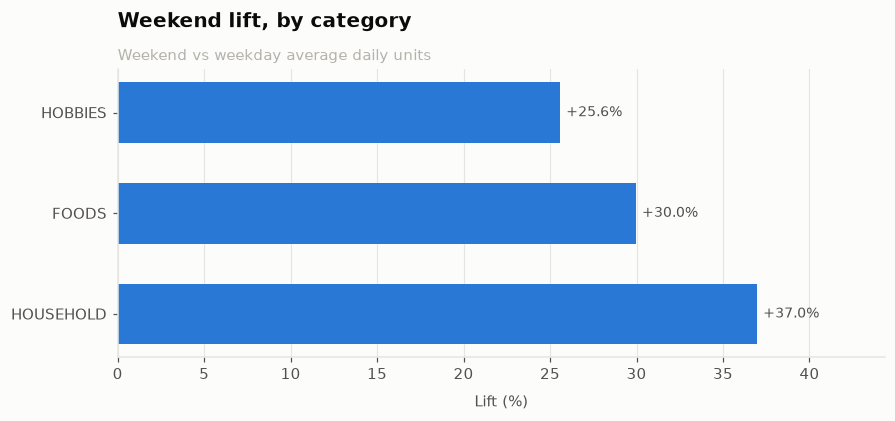

In [38]:
cw = daily_cat.merge(cal[["d_num", "weekday", "is_weekend"]], on="d_num")
cw = cw[cw["units"] > 0]
lift = (cw.groupby(["cat_id", "is_weekend"], observed=True)["units"].mean()
          .unstack("is_weekend"))
lift["lift_%"] = (lift[True] / lift[False] - 1) * 100
lift = lift.sort_values("lift_%", ascending=False)

fig, ax = plt.subplots(figsize=(9, 3.4))
bars = ax.barh(lift.index.astype(str), lift["lift_%"], color=BLUE, height=0.6)
ax.bar_label(bars, fmt=lambda v: f"{v:+.1f}%", padding=4, fontsize=9, color=INK2)
finish(ax, "Weekend lift, by category", "Weekend vs weekday average daily units",
       xlabel="Lift (%)", xgrid=True, yfmt=False)
ax.set_xlim(0, lift["lift_%"].max() * 1.2)
plt.show()

### Do sales increase during Christmas?

This one has a counter-intuitive answer, so it is worth looking at properly. The chart below overlays
each December, aligned on 25 December.

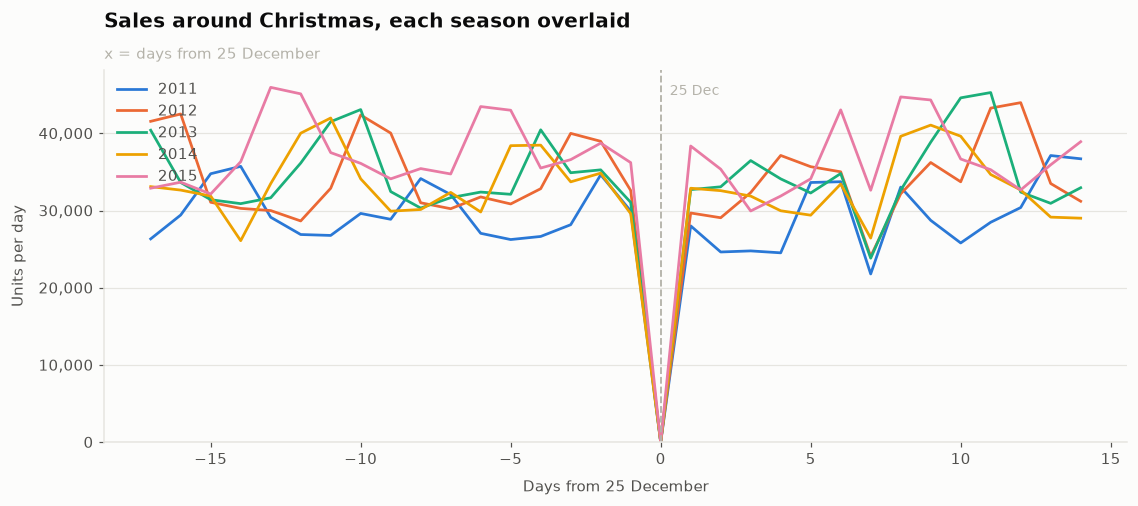

In [39]:
xmas = daily[(daily["date"].dt.month == 12) & (daily["date"].dt.day >= 8) |
             ((daily["date"].dt.month == 1) & (daily["date"].dt.day <= 8))].copy()
xmas["season"] = np.where(xmas["date"].dt.month == 12,
                          xmas["date"].dt.year, xmas["date"].dt.year - 1)
xmas["ref"]    = pd.to_datetime(pd.DataFrame({"year": xmas["season"], "month": 12, "day": 25}))
xmas["offset"] = (xmas["date"] - xmas["ref"]).dt.days
xmas = xmas[(xmas["offset"] >= -17) & (xmas["offset"] <= 14) &
            xmas["season"].between(2011, 2015)]

fig, ax = plt.subplots(figsize=(12, 4.4))
for i, (season, grp) in enumerate(xmas.groupby("season")):
    ax.plot(grp["offset"], grp["units"], lw=1.8, color=SERIES[i % 8], label=f"{season}")
ax.axvline(0, color=MUTED, lw=1.2, ls="--")
ax.text(0.3, ax.get_ylim()[1] * 0.96, "25 Dec", color=MUTED, fontsize=9, va="top")

finish(ax, "Sales around Christmas, each season overlaid",
       "x = days from 25 December", xlabel="Days from 25 December",
       ylabel="Units per day", legend=True)
ax.set_ylim(0, None)
plt.show()

In [40]:
dec = daily[(daily["date"].dt.month == 12) & ~daily["is_closed"]].copy()
dec_avg = dec.groupby("year")["units"].transform("mean")

print("each day vs that December's own average:")
for day in [20, 21, 22, 23, 24, 26, 27, 28]:
    sel = dec["date"].dt.day == day
    print(f"  Dec {day}: {(dec.loc[sel, 'units'] / dec_avg[sel]).mean() * 100 - 100:+5.1f}%")

print()
print("Dec 25 chain-wide units:",
      daily.loc[daily["event_name_1"] == "Christmas", "units"].tolist())

each day vs that December's own average:
  Dec 20:  -0.3%
  Dec 21:  +1.9%
  Dec 22:  +1.7%
  Dec 23:  +7.5%
  Dec 24:  -6.2%
  Dec 26:  -5.2%
  Dec 27:  -9.4%
  Dec 28:  -8.8%

Dec 25 chain-wide units: [13, 11, 20, 20, 14]


**No — and this is the most counter-intuitive finding in the dataset.**

* **25 December: the stores are closed.** Chain-wide units are 11–20 against a normal ~35,000. Those
  few units are recording artefacts, not sales.
* **There is a real but modest pre-Christmas ramp**, and it is concentrated on a single day:
  23 December runs **+7.5%** against that December's own average. The 20th–22nd are flat.
* **Christmas Eve is already down (−6.2%)**, and the days after are worse (−5.2%, −9.4%) — the
  shopping has finished and the stores are running down.

So "Christmas uplift" in this dataset is one busy day, one closed day, and a week-long slump. The
model needs the closure as a hard flag rather than a seasonal coefficient — which is why
`is_christmas` becomes its own feature in Part 2.

### Which months have the highest sales?

A raw monthly average would confound seasonality with the upward trend (later months in the sample sit
on a higher base). So we index each month against its own year's average and use only the four
complete years, 2012–2015.

In [ ]:
# Ratio-to-moving-average. Each day is divided by a *centred 365-day* mean, which
# strips the trend at daily resolution. Dividing by the calendar year's mean instead
# would leave the within-year trend in the numbers and systematically push January
# down and December up - that measures growth, not seasonality.
open_days = daily[~daily["is_closed"]].copy()
open_days["trend"] = open_days["units"].rolling(365, center=True, min_periods=180).mean()
open_days["ratio"] = open_days["units"] / open_days["trend"] * 100
month_index = open_days.groupby("month")["ratio"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3), gridspec_kw={"width_ratios": [1.15, 1]})

bars = axes[0].bar(MONTH_NAMES, month_index.values, color=BLUE, width=0.7)
axes[0].axhline(100, color=MUTED, lw=1.2, ls="--")
axes[0].bar_label(bars, fmt=lambda v: f"{v:.0f}", padding=3, fontsize=8.5, color=INK2)
finish(axes[0], "Seasonal index by month",
       "100 = the de-trended local average (ratio-to-moving-average)", ylabel="Index", yfmt=False)
axes[0].set_ylim(90, month_index.max() * 1.04)

pivot = (daily[~daily["is_closed"]].pivot_table(index="year", columns="month",
                                                values="units", aggfunc="mean"))
cmap = mpl.colors.LinearSegmentedColormap.from_list("blues", BLUE_RAMP)
im = axes[1].imshow(pivot.values, aspect="auto", cmap=cmap)
axes[1].set_xticks(range(12), MONTH_NAMES)
axes[1].set_yticks(range(len(pivot)), pivot.index.astype(str))
axes[1].grid(False)
cb = plt.colorbar(im, ax=axes[1], fraction=0.045)
cb.ax.tick_params(labelsize=8.5, color=INK2, labelcolor=INK2)
cb.outline.set_visible(False)
axes[1].set_title("Mean units per trading day", loc="left", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print(month_index.round(1).rename(index=dict(enumerate(MONTH_NAMES, start=1))).sort_values(
    ascending=False).to_string())

**August is the strongest month** (index 104.8), followed by June (103.4), July (103.2) and
September (102.7). **November is the weakest (94.9)**, then January (95.6) and December (96.6) — the
holiday quarter is the *low* season for this business.

The whole range is only **94.9 to 104.8, about ±5%**, and that is the real finding:
**month-of-year seasonality is minor here, and the weekly cycle dominates it several times over** — a
31% weekend lift against a 10% peak-to-trough spread across the entire year.

The heat-map on the right shows the same thing from the other direction: colour varies far more down
the year axis (growth) than across the month axis (seasonality).

## 1.4 Products

### Which products sell the most?

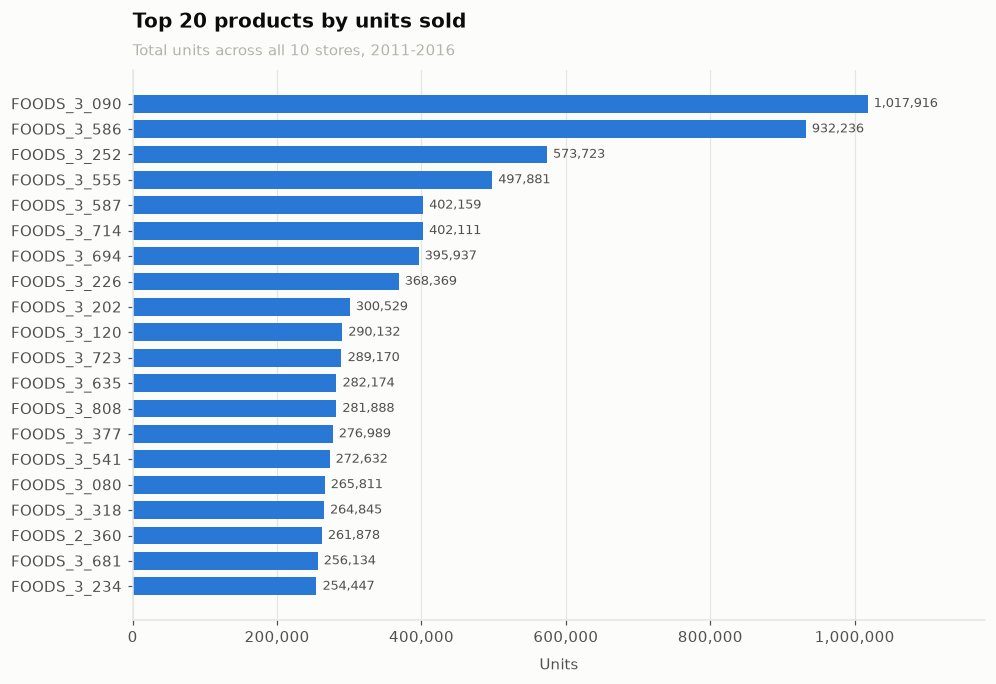

FOODS items in the top 20: 20/20


In [41]:
item_totals = (weekly.groupby("item_id", observed=True)
                     .agg(units=("units", "sum"), revenue=("revenue", "sum"))
                     .sort_values("units", ascending=False))
top20 = item_totals.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(top20.index.astype(str), top20["units"], color=BLUE, height=0.7)
ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}", padding=4, fontsize=8.5, color=INK2)
finish(ax, "Top 20 products by units sold",
       "Total units across all 10 stores, 2011-2016", xlabel="Units", xgrid=True)
ax.set_xlim(0, top20["units"].max() * 1.16)
plt.show()

print(f"FOODS items in the top 20: "
      f"{sum(i.startswith('FOODS') for i in item_totals.head(20).index)}/20")

Every one of the top 20 is a **FOODS** item and the leaders are all `FOODS_3`, headed by
`FOODS_3_090` at ~1.02M units — roughly 1.5% of every unit sold in the entire dataset, from a single
product. Concentration like this is worth quantifying:

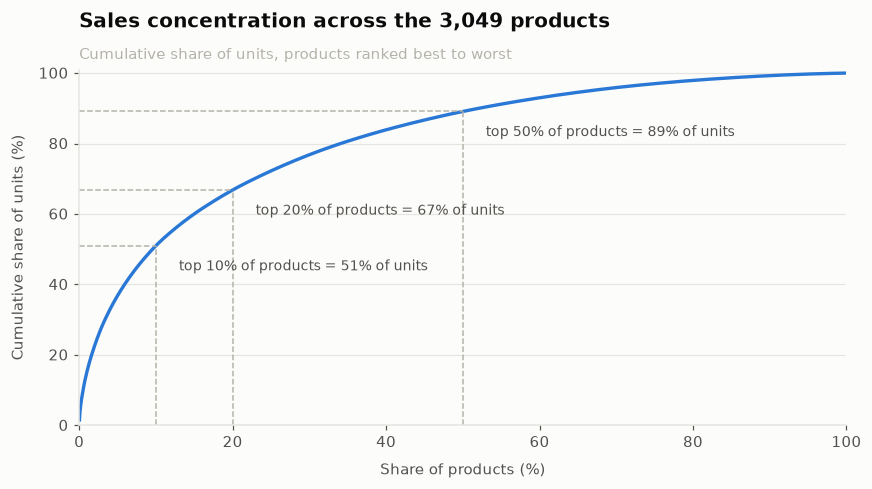

In [42]:
share = item_totals["units"].to_numpy(dtype="float64")
cum   = share.cumsum() / share.sum() * 100
rank_pct = np.arange(1, len(share) + 1) / len(share) * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(rank_pct, cum, lw=2.2, color=BLUE)
for mark in (10, 20, 50):
    y = np.interp(mark, rank_pct, cum)
    ax.plot([mark, mark], [0, y], color=MUTED, lw=1, ls="--")
    ax.plot([0, mark], [y, y], color=MUTED, lw=1, ls="--")
    ax.annotate(f"top {mark}% of products = {y:.0f}% of units",
                xy=(mark, y), xytext=(mark + 3, y - 7), fontsize=9, color=INK2)
finish(ax, "Sales concentration across the 3,049 products",
       "Cumulative share of units, products ranked best to worst",
       xlabel="Share of products (%)", ylabel="Cumulative share of units (%)", yfmt=False)
ax.set_xlim(0, 100); ax.set_ylim(0, 101)
plt.show()

The **top 10% of products carry 51% of all units, and the top 20% carry 67%** — a textbook Pareto
curve. The consequence for forecasting: the long tail is mostly intermittent, near-zero demand, so any
metric averaged over all 30,490 series is dominated by series whose correct answer is almost always
zero. That is exactly why the zero-rate and WMAPE get reported alongside MAE in Part 4.

### Which categories generate the most revenue?

Units and revenue are different questions, because average selling price differs sharply by category
(FOODS ~\$3.25, HOUSEHOLD ~\$5.47, HOBBIES ~\$5.33). Both are shares of the same total, so they can
share one axis.

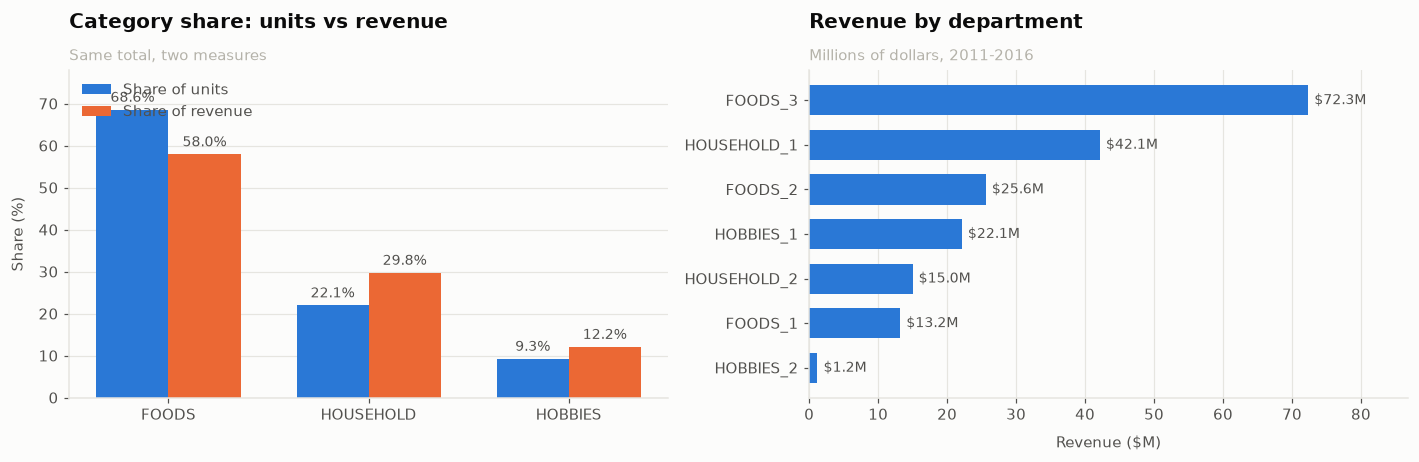

,units,revenue,avg_price,unit_share_%,rev_share_%
cat_id,,,,,
FOODS,45922427,1.111400e+08,3.25,68.62,58.01
HOUSEHOLD,14764090,5.711588e+07,5.47,22.06,29.81
HOBBIES,6240656,2.332164e+07,5.33,9.32,12.17


In [43]:
cat_totals = (weekly.groupby("cat_id", observed=True)
                    .agg(units=("units", "sum"), revenue=("revenue", "sum"),
                         avg_price=("sell_price", "mean"))
                    .sort_values("revenue", ascending=False))
cat_totals["unit_share_%"] = cat_totals["units"]   / cat_totals["units"].sum()   * 100
cat_totals["rev_share_%"]  = cat_totals["revenue"] / cat_totals["revenue"].sum() * 100

x = np.arange(len(cat_totals)); w = 0.36
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

b1 = axes[0].bar(x - w/2, cat_totals["unit_share_%"], w, color=BLUE,   label="Share of units")
b2 = axes[0].bar(x + w/2, cat_totals["rev_share_%"],  w, color=ORANGE, label="Share of revenue")
for b in (b1, b2):
    axes[0].bar_label(b, fmt=lambda v: f"{v:.1f}%", padding=3, fontsize=9, color=INK2)
axes[0].set_xticks(x, cat_totals.index.astype(str))
finish(axes[0], "Category share: units vs revenue",
       "Same total, two measures", ylabel="Share (%)", yfmt=False, legend=True)
axes[0].set_ylim(0, 78)

dept = (weekly.groupby("dept_id", observed=True)["revenue"].sum()
              .sort_values() / 1e6)
b3 = axes[1].barh(dept.index.astype(str), dept.values, color=BLUE, height=0.68)
axes[1].bar_label(b3, fmt=lambda v: f"${v:,.1f}M", padding=4, fontsize=9, color=INK2)
finish(axes[1], "Revenue by department", "Millions of dollars, 2011-2016",
       xlabel="Revenue ($M)", xgrid=True, yfmt=False)
axes[1].set_xlim(0, dept.max() * 1.2)

plt.tight_layout()
plt.show()

display(cat_totals.round(2))

**FOODS generates the most revenue** — \$111M, 58% of the total — but note the gap between the two
bars: FOODS is **69% of units and only 58% of revenue**, because it is the cheapest category.
HOUSEHOLD runs the other way (22% of units, 30% of revenue). `FOODS_3` alone is the single largest
department at ~\$77M.

That gap is exactly why a units model and a revenue model would rank products differently, and why the
target we forecast (**units**) has to be stated explicitly.

## 1.5 Stores

### Which store performs best? Which state performs best?

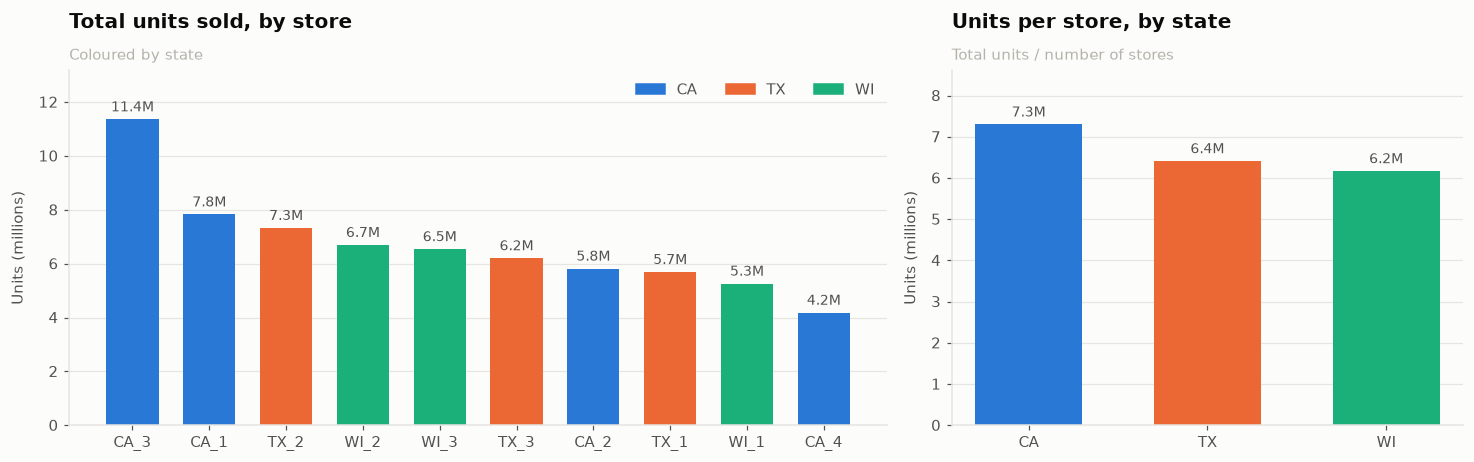

,units,state,revenue_$M
store_id,,,
CA_3,11363540,CA,32.7
CA_1,7832248,CA,23.0
TX_2,7329642,TX,20.9
WI_2,6697988,WI,18.1
WI_3,6542557,WI,17.3
TX_3,6205940,TX,18.2
CA_2,5818395,CA,17.8
TX_1,5692823,TX,16.0
WI_1,5261506,WI,15.1


,units,stores,units_per_store,revenue_$M
state_id,,,,
CA,29196717,4,7299179.0,86.0
TX,19228405,3,6409468.0,55.1
WI,18502051,3,6167350.0,50.5


In [44]:
store_totals = (weekly.groupby("store_id", observed=True)
                      .agg(units=("units", "sum"), revenue=("revenue", "sum")))
store_state  = (weekly[["store_id", "state_id"]].drop_duplicates()
                      .set_index("store_id")["state_id"])
store_totals["state"] = store_state
store_totals = store_totals.sort_values("units", ascending=False)

STATE_COLOUR = {"CA": BLUE, "TX": ORANGE, "WI": AQUA}
colours = [STATE_COLOUR[s] for s in store_totals["state"]]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3), gridspec_kw={"width_ratios": [1.6, 1]})

bars = axes[0].bar(store_totals.index.astype(str), store_totals["units"] / 1e6,
                   color=colours, width=0.68)
axes[0].bar_label(bars, fmt=lambda v: f"{v:.1f}M", padding=3, fontsize=9, color=INK2)
finish(axes[0], "Total units sold, by store", "Coloured by state", ylabel="Units (millions)",
       yfmt=False)
axes[0].set_ylim(0, store_totals["units"].max() / 1e6 * 1.16)
axes[0].legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in STATE_COLOUR.values()],
               list(STATE_COLOUR), loc="upper right", ncols=3)

state_totals = (weekly.groupby("state_id", observed=True)
                      .agg(units=("units", "sum"), revenue=("revenue", "sum"))
                      .sort_values("units", ascending=False))
state_totals["stores"] = weekly.groupby("state_id", observed=True)["store_id"].nunique()
state_totals["units_per_store"] = state_totals["units"] / state_totals["stores"]

b2 = axes[1].bar(state_totals.index.astype(str), state_totals["units_per_store"] / 1e6,
                 color=[STATE_COLOUR[s] for s in state_totals.index], width=0.6)
axes[1].bar_label(b2, fmt=lambda v: f"{v:.1f}M", padding=3, fontsize=9, color=INK2)
finish(axes[1], "Units per store, by state", "Total units / number of stores",
       ylabel="Units (millions)", yfmt=False)
axes[1].set_ylim(0, (state_totals["units_per_store"] / 1e6).max() * 1.18)

plt.tight_layout()
plt.show()

display(store_totals.assign(**{"revenue_$M": store_totals["revenue"] / 1e6})
                    .drop(columns="revenue").round({"units": 0, "revenue_$M": 1}))
display(state_totals.assign(**{"revenue_$M": state_totals["revenue"] / 1e6})
                    .drop(columns="revenue").round({"units": 0, "revenue_$M": 1,
                                                    "units_per_store": 0}))

**CA_3 is the best-performing store by a wide margin** — 11.4M units and \$32.7M revenue, 45% ahead of
the second-placed CA_1 and nearly **2.7x the weakest store, CA_4** (4.2M units). That spread inside a
single state is larger than the spread between states.

**California is the largest state in total** (29.2M units vs 19.2M for TX and 18.5M for WI) — but it
also has 4 stores to the others' 3. Normalised **per store**, California's advantage almost vanishes
(7.3M vs 6.4M and 6.2M), and it is carried entirely by CA_3.

Do the stores move together over time, or are they diverging?

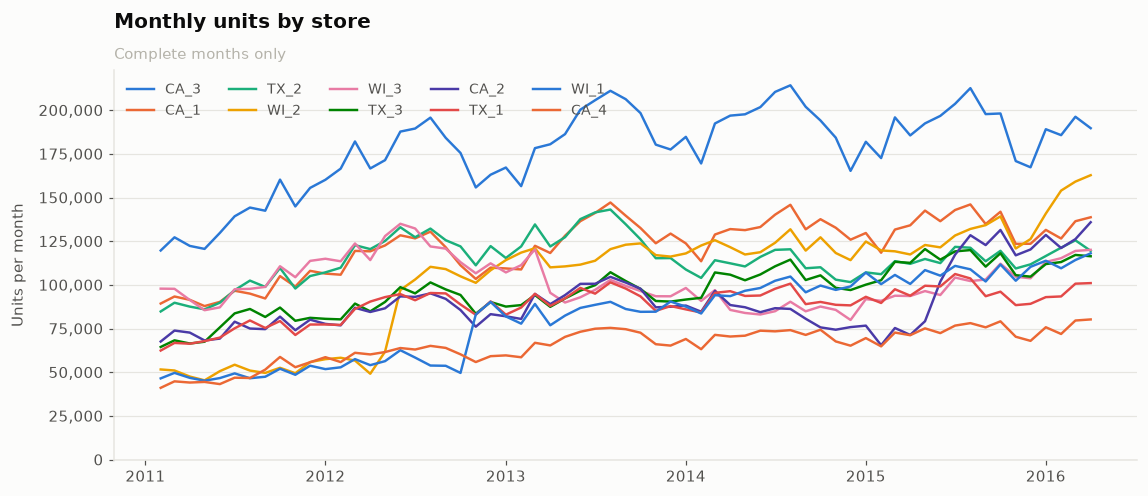

In [45]:
store_month = (daily_store.groupby(["store_id", pd.Grouper(key="date", freq="MS")],
                                   observed=True)["units"].sum().reset_index())
store_month = store_month[store_month["date"].between("2011-02-01", "2016-04-01")]

fig, ax = plt.subplots(figsize=(12, 4.6))
order = store_totals.index.tolist()
for i, s in enumerate(order):
    g = store_month[store_month["store_id"] == s]
    ax.plot(g["date"], g["units"], lw=1.6, color=SERIES[i % 8], label=s)
finish(ax, "Monthly units by store", "Complete months only", ylabel="Units per month")
ax.set_ylim(0, None)
ax.legend(loc="upper left", ncols=5, fontsize=9)
plt.show()

Two structural breaks stand out and both are the kind of thing a forecaster has to know about:
**CA_2 collapses in mid-2015 and then recovers to a new, much higher level**, and **TX_2 steps up
sharply in 2013**. These are store-level events (a remodel, a re-opening, a catchment change), not
noise — a model trained on the pre-break history of those stores will systematically under-forecast
them.

## 1.6 Prices

### Does price affect sales?

Comparing raw price against raw units across products would mostly measure *which products are
expensive*, not *what happens when a price changes*. So we compare each (item, store) series against
**its own** history:

* `rel_price` = this week's price ÷ the highest price that series ever charged
* `units_norm` = this week's units ÷ that series' average weekly units

Both are within-series, so a cheap high-volume item and an expensive low-volume item contribute on the
same scale.

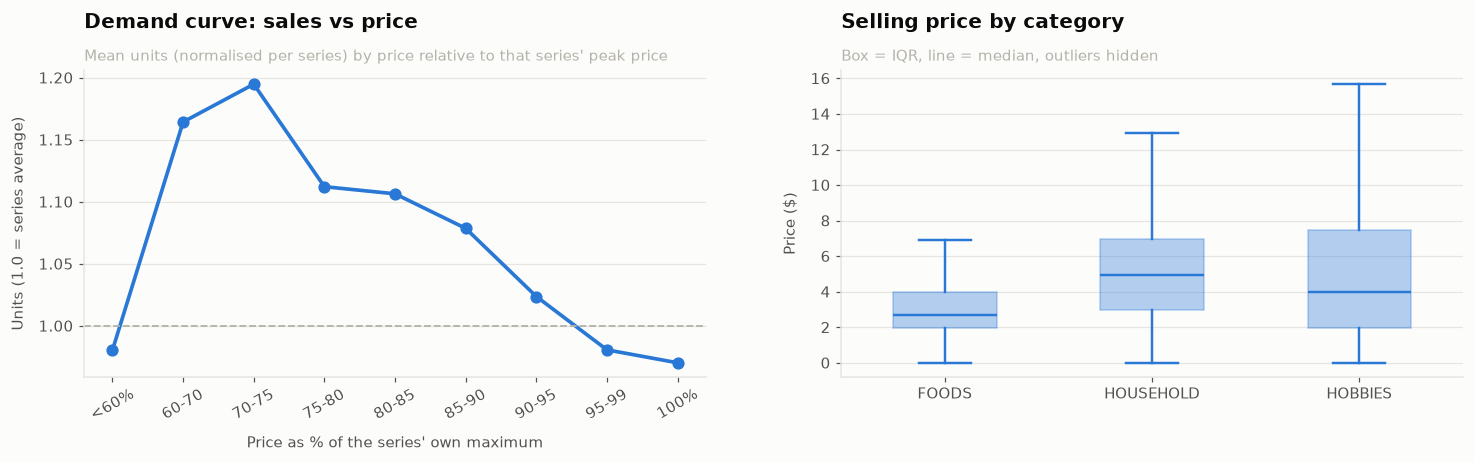

,mean_units_norm,weeks
price_bin,,
<60%,0.981,19541
60-70,1.164,44008
70-75,1.195,47895
75-80,1.112,123109
80-85,1.107,260585
85-90,1.079,564905
90-95,1.024,1066813
95-99,0.981,808704
100%,0.970,3783601


In [46]:
w = weekly[weekly["sell_price"].notna()].copy()
grp = w.groupby(["item_id", "store_id"], observed=True)
w["price_max"]  = grp["sell_price"].transform("max")
w["mean_units"] = grp["units"].transform("mean").astype("float32")
w["rel_price"]  = (w["sell_price"] / w["price_max"]).astype("float32")
w["units_norm"] = (w["units"] / w["mean_units"].replace(0, np.nan)).astype("float32")
w["discount_%"] = ((1 - w["rel_price"]) * 100).astype("float32")

bins   = [0, .60, .70, .75, .80, .85, .90, .95, .99, 1.001]
labels = ["<60%", "60-70", "70-75", "75-80", "80-85", "85-90", "90-95", "95-99", "100%"]
w["price_bin"] = pd.cut(w["rel_price"], bins=bins, labels=labels, include_lowest=True)

curve = w.groupby("price_bin", observed=True)["units_norm"].mean()
count = w.groupby("price_bin", observed=True).size()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))

axes[0].plot(range(len(curve)), curve.values, lw=2.4, color=BLUE, marker="o", ms=7)
axes[0].axhline(1.0, color=MUTED, lw=1.2, ls="--")
axes[0].set_xticks(range(len(curve)), curve.index.astype(str), rotation=30)
finish(axes[0], "Demand curve: sales vs price",
       "Mean units (normalised per series) by price relative to that series' peak price",
       xlabel="Price as % of the series' own maximum", ylabel="Units (1.0 = series average)",
       yfmt=False)

box = [w.loc[w["cat_id"] == c, "sell_price"].to_numpy() for c in cat_totals.index]
bp = axes[1].boxplot(box, tick_labels=cat_totals.index.astype(str), showfliers=False,
                     patch_artist=True, widths=0.5)
for patch in bp["boxes"]:
    patch.set_facecolor(BLUE); patch.set_alpha(0.35); patch.set_edgecolor(BLUE)
for part in ("whiskers", "caps", "medians"):
    for ln in bp[part]:
        ln.set_color(BLUE); ln.set_linewidth(1.6)
finish(axes[1], "Selling price by category", "Box = IQR, line = median, outliers hidden",
       ylabel="Price ($)", yfmt=False)

plt.tight_layout()
plt.show()

display(pd.DataFrame({"mean_units_norm": curve.round(3), "weeks": count}))

**Yes, and the curve has a twist worth understanding.** Across most of the range demand behaves
exactly as theory says: at full price a series sells **0.97x** its own average, and it climbs steadily
as price falls — 1.02x at 90–95%, 1.11x at 75–80%, peaking at **1.20x at 70–75%** of the series' own
maximum.

But at the deepest discounts it **turns back down**: below 60% of peak price a series sells only
**0.98x** its average. That is not the demand curve failing, it is a selection effect — permanent,
very deep markdowns are mostly clearance on products being discontinued, so the price is low *because*
demand died, not the other way round. Note how thin that bin is: 19.5k weeks against 3.8M at full
price.

To put a single number on it, estimate the **price elasticity of demand** with item×store fixed
effects — regress log units on log price *after* removing each series' own mean, so the estimate comes
only from price changes within a series, never from differences between products.

In [47]:
e = w[(w["units"] > 0)].copy()
e["lp"] = np.log(e["sell_price"].to_numpy(dtype="float64"))
e["lu"] = np.log(e["units"].to_numpy(dtype="float64"))
g2 = e.groupby(["item_id", "store_id"], observed=True)
lp_d = e["lp"] - g2["lp"].transform("mean")
lu_d = e["lu"] - g2["lu"].transform("mean")
beta = float((lp_d * lu_d).sum() / (lp_d ** 2).sum())

print(f"within-series price elasticity of demand: {beta:.2f}")
print(f"-> a 10% price cut is associated with roughly a {-beta*10:.0f}% increase in units")
del e, g2, lp_d, lu_d
_ = gc.collect()

within-series price elasticity of demand: -0.64
-> a 10% price cut is associated with roughly a 6% increase in units


An elasticity of about **−0.64** means demand here is **inelastic**: cutting price by 10% moves only
~6% more units, so a broad price cut would *reduce* revenue. That is a very different message from the
raw promotion lift below, and the two are reconciled by what a "promotion" actually selects for —
a handful of items with genuinely elastic demand, not the catalogue average.

### Do promotions increase sales?

The M5 data has **no promotion flag** — this is a modelling decision we have to make ourselves. The
standard proxy is a price meaningfully below the series' own regular price, so we define:

> **promotion week** = selling price is more than 5% below that (item, store) series' maximum price.

It is a proxy, not ground truth: a permanent price cut late in a product's life also trips it. That
caveat belongs in any write-up of the result.

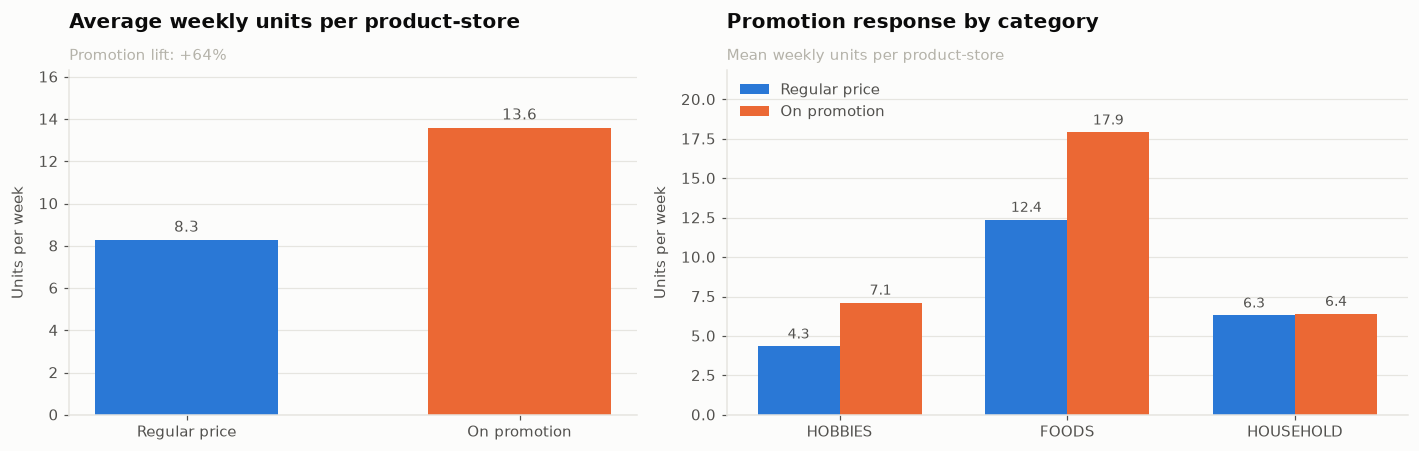

on_promo,False,True,lift_%
cat_id,,,
HOBBIES,4.34,7.12,64.10
FOODS,12.37,17.91,44.75
HOUSEHOLD,6.30,6.41,1.64


In [48]:
w["on_promo"] = w["discount_%"] > 5

promo = w.groupby("on_promo", observed=True)["units"].agg(["mean", "size"])
promo_lift = promo.loc[True, "mean"] / promo.loc[False, "mean"] - 1

by_cat = (w.groupby(["cat_id", "on_promo"], observed=True)["units"].mean()
            .unstack("on_promo"))
by_cat["lift_%"] = (by_cat[True] / by_cat[False] - 1) * 100
by_cat = by_cat.sort_values("lift_%", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 1.2]})

b1 = axes[0].bar(["Regular price", "On promotion"],
                 [promo.loc[False, "mean"], promo.loc[True, "mean"]],
                 color=[BLUE, ORANGE], width=0.55)
axes[0].bar_label(b1, fmt=lambda v: f"{v:.1f}", padding=3, fontsize=10, color=INK2)
finish(axes[0], "Average weekly units per product-store",
       f"Promotion lift: {promo_lift:+.0%}", ylabel="Units per week", yfmt=False)
axes[0].set_ylim(0, promo.loc[True, "mean"] * 1.2)

x = np.arange(len(by_cat)); wd = 0.36
c1 = axes[1].bar(x - wd/2, by_cat[False], wd, color=BLUE,   label="Regular price")
c2 = axes[1].bar(x + wd/2, by_cat[True],  wd, color=ORANGE, label="On promotion")
for b in (c1, c2):
    axes[1].bar_label(b, fmt=lambda v: f"{v:.1f}", padding=3, fontsize=9, color=INK2)
axes[1].set_xticks(x, by_cat.index.astype(str))
finish(axes[1], "Promotion response by category", "Mean weekly units per product-store",
       ylabel="Units per week", yfmt=False, legend=True)
axes[1].set_ylim(0, by_cat[True].max() * 1.22)

plt.tight_layout()
plt.show()

display(by_cat.round(2))

**Yes — but not everywhere.** Chain-wide a promotion week averages **+64%** more units than a regular
week. Split by category the effect is wildly uneven:

* **HOBBIES +64.1%** (4.34 -> 7.12 units per week)
* **FOODS +44.8%** (12.37 -> 17.91)
* **HOUSEHOLD +1.6%** (6.30 -> 6.41) — essentially **no response at all**

The HOUSEHOLD result is the interesting one, and it fits the low overall elasticity: a household
staple gets bought when it runs out, not when it is cheap. Rolling the three categories into a single
"promotions work" headline would hide a real difference in shopper behaviour, and would give a
merchandiser bad advice.

### SNAP benefit days

`calendar.csv` carries `snap_CA / snap_TX / snap_WI` — days on which food-stamp (SNAP) benefits can be
spent in that state. This is a demand driver unique to this dataset and it is genuinely large.

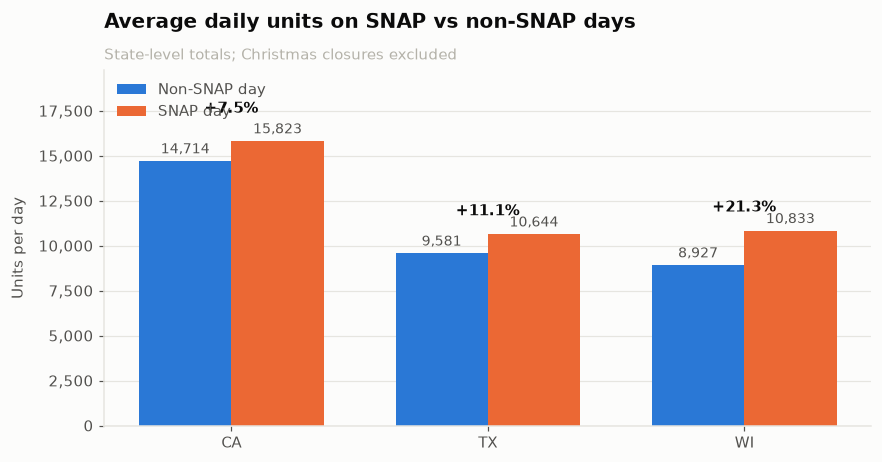

,non_snap,snap,lift_%
state,,,
CA,14714.3,15823.4,7.5
TX,9580.7,10643.5,11.1
WI,8926.8,10832.7,21.3


In [49]:
snap_rows = []
for st in ["CA", "TX", "WI"]:
    s = daily_state[daily_state["state_id"] == st].merge(
        cal[["d_num", f"snap_{st}"]], on="d_num").rename(columns={f"snap_{st}": "snap"})
    s = s[s["units"] > 1_000]                       # drop the Christmas closures
    m = s.groupby("snap")["units"].mean()
    snap_rows.append({"state": st, "non_snap": m[0], "snap": m[1],
                      "lift_%": (m[1] / m[0] - 1) * 100})
snap_tab = pd.DataFrame(snap_rows).set_index("state")

x = np.arange(len(snap_tab)); wd = 0.36
fig, ax = plt.subplots(figsize=(9, 4.2))
b1 = ax.bar(x - wd/2, snap_tab["non_snap"], wd, color=BLUE,   label="Non-SNAP day")
b2 = ax.bar(x + wd/2, snap_tab["snap"],     wd, color=ORANGE, label="SNAP day")
for b in (b1, b2):
    ax.bar_label(b, fmt=lambda v: f"{v:,.0f}", padding=3, fontsize=9, color=INK2)
for i, r in enumerate(snap_tab.itertuples()):
    ax.text(i, max(r.non_snap, r.snap) * 1.10, f"{r._3:+.1f}%",
            ha="center", fontsize=10, color=INK, fontweight="bold")
ax.set_xticks(x, snap_tab.index)
finish(ax, "Average daily units on SNAP vs non-SNAP days",
       "State-level totals; Christmas closures excluded", ylabel="Units per day", legend=True)
ax.set_ylim(0, snap_tab["snap"].max() * 1.25)
plt.show()

display(snap_tab.round(1))

SNAP days lift sales **+7.5% in California, +11.1% in Texas and +21.3% in Wisconsin**. The variation
across states is as informative as the effect itself, and it means the SNAP flag has to be applied
**per state**, not chain-wide.

### Sales during events

`calendar.csv` labels 162 of the 1,941 days with a holiday or event.

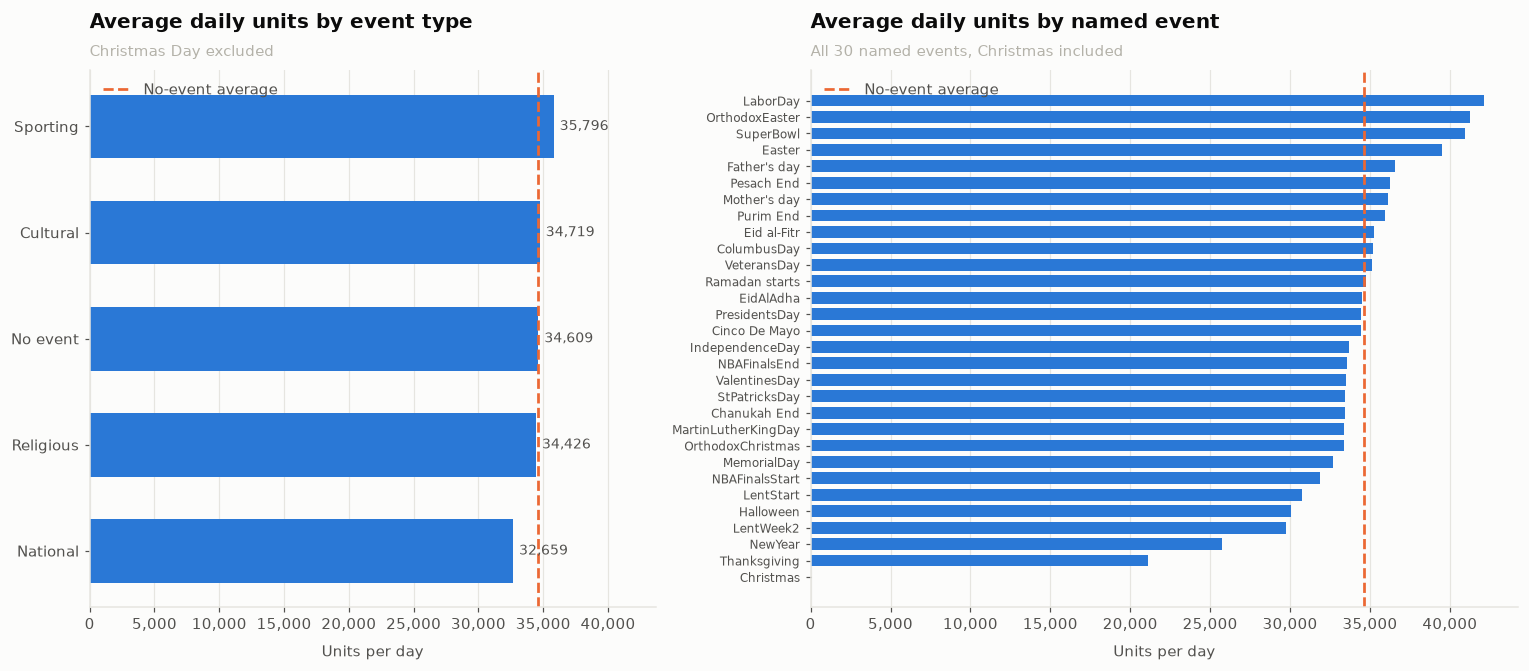

no-event baseline: 34,609 units/day

biggest positive events:
event_name_1
Pesach End         4.8
Father's day       5.6
Easter            14.2
SuperBowl         18.2
OrthodoxEaster    19.1
LaborDay          21.8

biggest negative events:
event_name_1
Christmas      -100.0
Thanksgiving    -38.9
NewYear         -25.5
LentWeek2       -14.0
Halloween       -13.1


In [50]:
baseline = daily.loc[daily["event_name_1"].isna() & ~daily["is_closed"], "units"].mean()

by_type = (daily[~daily["is_closed"]].assign(
              t=lambda d: d["event_type_1"].fillna("No event"))
              .groupby("t")["units"].mean().sort_values())

by_event = daily.groupby("event_name_1", observed=True)["units"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2), gridspec_kw={"width_ratios": [1, 1.25]})

b1 = axes[0].barh(by_type.index.astype(str), by_type.values, color=BLUE, height=0.6)
axes[0].axvline(baseline, color=ORANGE, lw=1.8, ls="--", label="No-event average")
axes[0].bar_label(b1, fmt=lambda v: f"{v:,.0f}", padding=4, fontsize=9, color=INK2)
finish(axes[0], "Average daily units by event type", "Christmas Day excluded",
       xlabel="Units per day", xgrid=True, legend=True)
axes[0].set_xlim(0, by_type.max() * 1.22)

b2 = axes[1].barh(by_event.index.astype(str), by_event.values, color=BLUE, height=0.72)
axes[1].axvline(baseline, color=ORANGE, lw=1.8, ls="--", label="No-event average")
finish(axes[1], "Average daily units by named event",
       "All 30 named events, Christmas included", xlabel="Units per day", xgrid=True,
       legend=True)
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

print(f"no-event baseline: {baseline:,.0f} units/day")
print()
print("biggest positive events:"); print((by_event.tail(6) / baseline - 1).mul(100).round(1).to_string())
print(); print("biggest negative events:"); print((by_event.head(5) / baseline - 1).mul(100).round(1).to_string())

Events split cleanly into three groups:

* **Christmas Day: −100%.** The stores are shut. This is a hard structural zero, not a demand effect.
* **Real slumps: Thanksgiving (−39%) and New Year (−26%)** — reduced trading, plus the shopping having
  already happened.
* **Real peaks: Labor Day (+22%), Super Bowl (+18%), Easter (+14%)** — food-and-gathering events, which
  fits a grocery-weighted basket.

`National` events average *below* the no-event baseline precisely because Thanksgiving, New Year and
Christmas sit in that bucket; `Sporting` events average above it. That is why the model gets both the
**event type** and specific day flags rather than a single "is holiday" boolean.

---

## 1.7 What the EDA tells us

| Question | Answer |
|---|---|
| How are sales changing over time? | Growing, unevenly: **+25.4% (2012), +9.2% (2013), −0.4% (2014), +5.4% (2015), +10.3% (2016)**. The average trading day went from 26.4k units in 2011 to 41.8k in 2016. |
| Do sales increase at weekends? | **Yes — +30.9%.** Weekend 41,580 vs weekday 31,753 units. Saturday (41.7k) is the peak, Wednesday (30.2k) the trough. The dominant pattern in the data. |
| Do sales increase during Christmas? | **No — the opposite.** The stores **close** on 25 December (11–20 units chain-wide). The only uplift is 23 December at **+7.5%** vs that December's own average; the 24th (−6.2%) and 26th–27th (−5.2%, −9.4%) are down, and December indexes at 96.6. |
| Which months have the highest sales? | **August (104.8)**, then June (103.4), July (103.2), September (102.7). **November is weakest (94.9)**. The whole range is ±5% — small next to the weekly cycle. |
| Which products sell the most? | `FOODS_3_090` (~1.02M units), `FOODS_3_586` (~932k). All of the top 20 are FOODS. **Top 10% of products = 51% of units; top 20% = 67%.** |
| Which categories generate the most revenue? | **FOODS — \$111.1M, 58.0%** of revenue, but 68.6% of units (cheapest category, \$3.25 average). HOUSEHOLD is 22.1% of units and 29.8% of revenue. |
| Which store performs best? | **CA_3** — 11.4M units / \$32.7M, 45% ahead of CA_1 and 2.7x the weakest store (CA_4, 4.2M). |
| Which state performs best? | CA in total (29.2M units), but it has 4 stores; **per store the three are close** (7.3M / 6.4M / 6.2M) and CA's lead is essentially CA_3 alone. |
| Does price affect sales? | **Yes**, but demand is **inelastic**: within-series elasticity ≈ **−0.64**, so a 10% price cut goes with only ~6% more units. Units rise to 1.20x as price falls to 70–75% of peak, then turn back down below 60% (clearance selection). |
| Do promotions increase sales? | **Yes overall (+64%), but not uniformly**: HOBBIES +64.1%, FOODS +44.8%, **HOUSEHOLD +1.6% — no real response**. |

**Extras the EDA turned up that the brief did not ask for, but that matter for the model:**

* **SNAP days** lift sales +7.5% (CA), +11.1% (TX), +21.3% (WI) — a large, state-specific driver.
* **Structural breaks** in CA_2 (mid-2015) and TX_2 (2013) mean store history is not stationary.
* **20.7% of (item, store, week) cells have no price** because the product was not stocked yet — those
  rows must be dropped rather than treated as zero demand.

These directly set the feature list in Part 2: day-of-week and lag-7 first, then price and discount,
then SNAP and event flags, then store/item identity.

---

# Part 2 — Feature engineering

This is where the project becomes interesting. A tree model has no idea what "last Tuesday" means —
every piece of temporal structure the EDA just uncovered has to be handed to it as a **column**.

We build four families of features:

| Family | Examples | What it encodes |
|---|---|---|
| **Calendar** | `year`, `month`, `week`, `day_of_week`, `day_of_month`, `quarter` | the weekly cycle (the strongest signal we found), seasonality, trend |
| **Event / SNAP** | `is_event`, `event_type_code`, `is_christmas`, `snap` | the holiday and benefit-day effects from §1.6 |
| **Price** | `sell_price`, `price_rel`, `discount_pct`, `price_change_7` | the demand curve and promotion lift from §1.6 |
| **Lag & rolling** | `lag_1 … lag_28`, `rmean_7 … rstd_28` | "what happened previously" — the series' own recent history |

### Scale: why we model a sample

The full problem is 30,490 series x 1,941 days = **59M rows**. Adding ~30 float features to that is
~7 GB before a model sees it, which does not fit on an 8 GB machine. So we model a **stratified
sample**: 400 items (drawn proportionally from HOBBIES / HOUSEHOLD / FOODS) x all 10 stores, over the
most recent ~2.5 years.

That is a deliberate, stated trade-off, not a shortcut we hide — every method below is written so that
raising `N_ITEMS_SAMPLE` to 3,049 and `FIRST_DAY` to 1 on a bigger machine changes nothing except the
runtime.

In [51]:
# ---- modelling scope -------------------------------------------------------
N_ITEMS_SAMPLE = 400     # items sampled from 3,049 (stratified by category)
FIRST_DAY      = 1000    # d_1000 = 2013-10-24; earlier history is dropped
RANDOM_STATE   = 42
# ----------------------------------------------------------------------------

item_meta = sales[["item_id", "cat_id"]].drop_duplicates()
frac = N_ITEMS_SAMPLE / item_meta["item_id"].nunique()

parts = []
for c, g in item_meta.groupby("cat_id", observed=True):
    parts.append(g.sample(n=max(1, round(len(g) * frac)), random_state=RANDOM_STATE))
sampled_items = pd.concat(parts)["item_id"]

print(f"sampled {len(sampled_items)} items")
print(pd.concat(parts)["cat_id"].value_counts().to_string())

sampled 400 items
cat_id
FOODS        189
HOUSEHOLD    137
HOBBIES       74


In [53]:
keep = (df["d_num"].to_numpy() >= FIRST_DAY) & df["item_id"].isin(sampled_items).to_numpy()

model_df = df.loc[keep, ["item_id", "dept_id", "cat_id", "store_id", "state_id",
                         "d_num", "sales"]].copy()
for c in ["item_id", "dept_id", "cat_id", "store_id", "state_id"]:
    model_df[c] = model_df[c].cat.remove_unused_categories()

# Sorting is not cosmetic: every lag and rolling feature below assumes each
# (item, store) series is contiguous and in chronological order.
model_df = model_df.sort_values(["item_id", "store_id", "d_num"],
                                kind="stable").reset_index(drop=True)
del keep
gc.collect()

n_ser = model_df.groupby(["item_id", "store_id"], observed=True).ngroups
print(f"{len(model_df):,} rows | {n_ser:,} series | "
      f"d_{model_df['d_num'].min()} -> d_{model_df['d_num'].max()} | "
      f"{model_df.memory_usage(deep=True).sum()/1e6:,.0f} MB")
model_df.head()

3,768,000 rows | 4,000 series | d_1000 -> d_1941 | 38 MB


,item_id,dept_id,cat_id,store_id,state_id,d_num,sales
0,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1000,0
1,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1001,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1002,0
3,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1003,0
4,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1004,0


## 2.1 Calendar features

Straight lookups against `cal`, again by position rather than by merge.

`day_of_week` and `is_weekend` are the two that matter most — the EDA put the weekend lift at +31%,
the largest effect in the dataset.

In [54]:
idx = model_df["d_num"].to_numpy() - 1

model_df["date"]         = cal["date"].to_numpy()[idx]
model_df["year"]         = cal["year"].to_numpy(dtype="int16")[idx]
model_df["month"]        = cal["month"].to_numpy(dtype="int8")[idx]
model_df["week"]         = cal["week"].to_numpy(dtype="int8")[idx]
model_df["day_of_week"]  = cal["date"].dt.dayofweek.to_numpy(dtype="int8")[idx]   # 0 = Monday
model_df["day_of_month"] = cal["day_of_month"].to_numpy(dtype="int8")[idx]
model_df["quarter"]      = cal["quarter"].to_numpy(dtype="int8")[idx]
model_df["day_of_year"]  = cal["day_of_year"].to_numpy(dtype="int16")[idx]
model_df["is_weekend"]   = cal["is_weekend"].to_numpy(dtype="int8")[idx]

model_df[["date", "year", "month", "week", "day_of_week",
          "day_of_month", "quarter", "day_of_year", "is_weekend"]].head()

,date,year,month,week,day_of_week,day_of_month,quarter,day_of_year,is_weekend
0,2013-10-24,2013,10,43,3,24,4,297,0
1,2013-10-25,2013,10,43,4,25,4,298,0
2,2013-10-26,2013,10,43,5,26,4,299,1
3,2013-10-27,2013,10,43,6,27,4,300,1
4,2013-10-28,2013,10,44,0,28,4,301,0


## 2.2 Event and SNAP features

SNAP has to be resolved **per state** — the EDA showed the effect ranges from +7.5% in California to
+21.3% in Wisconsin, so a single chain-wide flag would blur three different behaviours. We index a
(3 x n_days) matrix with the row's state and day at once.

Christmas gets its own flag because it is not a demand effect at all — the stores are shut, and it is
the one day the model should predict a hard zero.

In [55]:
STATES = ["CA", "TX", "WI"]
assert list(model_df["state_id"].cat.categories) == STATES

snap_matrix = np.stack([cal[f"snap_{s}"].to_numpy(dtype="int8") for s in STATES])  # (3, n_days)
state_codes = model_df["state_id"].cat.codes.to_numpy()
model_df["snap"] = snap_matrix[state_codes, idx]

event_type = pd.Categorical(cal["event_type_1"].fillna("NoEvent"))
EVENT_TYPES = list(event_type.categories)
model_df["event_type_code"] = event_type.codes.astype("int8")[idx]
model_df["is_event"]     = cal["event_name_1"].notna().to_numpy(dtype="int8")[idx]
model_df["is_christmas"] = ((cal["event_name_1"] == "Christmas").fillna(False)
                            .to_numpy(dtype="int8"))[idx]

print("event type codes:", dict(enumerate(EVENT_TYPES)))
print(model_df[["snap", "event_type_code", "is_event", "is_christmas"]].mean().round(4).to_string())

event type codes: {0: 'Cultural', 1: 'National', 2: 'NoEvent', 3: 'Religious', 4: 'Sporting'}
snap               0.3291
event_type_code    1.9745
is_event           0.0828
is_christmas       0.0032


## 2.3 Price features

`sell_prices.csv` is weekly, so we join it on `wm_yr_wk`. Both key columns are cast to the *same*
categorical dtype first — merging two `category` columns with different category sets silently falls
back to object, which on millions of rows is the difference between seconds and minutes.

Raw price is not very useful on its own (it mostly says *which product this is*). The informative
features are relative:

* `price_rel` — price ÷ the highest price this series has charged **so far**
* `discount_pct` — how far below that running peak it is priced *right now*
* `price_change_7` — the week-on-week price move, which is what a shopper actually reacts to

The word *so far* is doing real work. The obvious implementation is `groupby(...).transform("max")`,
a single maximum over the whole series — but that maximum may come from a week in the future, and a
feature that peeks at next month's price list is leakage of exactly the kind §2.5 is about. `cummax()`
is the honest version: at day *t* it has only ever seen prices up to day *t*. It is also the version
the serving module has to use, because at prediction time the future genuinely does not exist yet —
and §6.9 asserts the two agree.

In [ ]:
model_df["wm_yr_wk"] = cal["wm_yr_wk"].to_numpy(dtype="int32")[idx]

p = prices[prices["item_id"].isin(sampled_items)].copy()
p["item_id"]  = p["item_id"].astype(model_df["item_id"].dtype)
p["store_id"] = p["store_id"].astype(model_df["store_id"].dtype)

model_df = model_df.merge(p, on=["store_id", "item_id", "wm_yr_wk"], how="left")
del p
gc.collect()

grp_p      = model_df.groupby(["item_id", "store_id"], observed=True)["sell_price"]
price_max  = grp_p.cummax()          # expanding, not global: see the note above
price_lag7 = grp_p.shift(7)

price_rel = (model_df["sell_price"] / price_max).astype("float32")
model_df = model_df.assign(
    price_rel      = price_rel,
    discount_pct   = ((1 - price_rel) * 100).astype("float32"),
    price_change_7 = ((model_df["sell_price"] / price_lag7 - 1) * 100).astype("float32").fillna(0),
)
del grp_p, price_max, price_lag7, price_rel

print(f"rows with no price (product not stocked yet): "
      f"{model_df['sell_price'].isna().mean():.1%}")
model_df[["sell_price", "price_rel", "discount_pct", "price_change_7"]].describe().round(3)

## 2.4 Lag features

The model needs to know **what happened previously**. A lag feature is the series' own value shifted
forward in time:

```python
model_df["lag_7"] = (
    model_df.groupby(["item_id", "store_id"])["sales"]
            .shift(7)
)
```

which tells the model: *"how many units did this product sell in this store exactly one week ago?"*

The `groupby` is essential. A plain `.shift(7)` on the whole frame would pull the last 7 values of one
product's history into the first 7 rows of the next product's — silently, with no error.

We build `lag_1`, `lag_7`, `lag_14` and `lag_28`. `lag_7` and its multiples are the important ones,
because they align the same weekday against the same weekday.

In [57]:
LAGS = [1, 7, 14, 28]

grp = model_df.groupby(["item_id", "store_id"], observed=True)["sales"]
model_df = model_df.assign(**{f"lag_{L}": grp.shift(L).astype("float32") for L in LAGS})
del grp

model_df[["item_id", "store_id", "d_num", "sales"] + [f"lag_{L}" for L in LAGS]].head(30)

,item_id,store_id,d_num,sales,lag_1,lag_7,lag_14,lag_28
0,HOBBIES_1_003,CA_1,1000,0,NaN,NaN,NaN,NaN
1,HOBBIES_1_003,CA_1,1001,0,0.0,NaN,NaN,NaN
2,HOBBIES_1_003,CA_1,1002,0,0.0,NaN,NaN,NaN
3,HOBBIES_1_003,CA_1,1003,0,0.0,NaN,NaN,NaN
4,HOBBIES_1_003,CA_1,1004,0,0.0,NaN,NaN,NaN
5,HOBBIES_1_003,CA_1,1005,0,0.0,NaN,NaN,NaN
6,HOBBIES_1_003,CA_1,1006,0,0.0,NaN,NaN,NaN
7,HOBBIES_1_003,CA_1,1007,0,0.0,0.0,NaN,NaN
8,HOBBIES_1_003,CA_1,1008,0,0.0,0.0,NaN,NaN
9,HOBBIES_1_003,CA_1,1009,0,0.0,0.0,NaN,NaN


## 2.5 Rolling features

A single lag is noisy — one bad Tuesday should not move the forecast much. Rolling statistics smooth
the recent history into a level (`mean`) and a volatility (`std`).

```python
model_df["rmean_7"] = (
    model_df.groupby(["item_id", "store_id"])["sales"]
            .transform(lambda x: x.shift(1).rolling(7).mean())
)
```

**Notice the `shift(1)`. That is the whole point.**

`rolling(7).mean()` on its own includes *today's* value in today's 7-day window. The model would then
be handed a number computed partly from the answer it is being asked to predict. Training accuracy
would look excellent and live accuracy would be terrible, because at forecast time today's sales do
not exist yet.

That is **data leakage** — a feature that carries information which would not be available at the
moment the prediction has to be made. The `shift(1)` makes the window end *yesterday*, so every value
in it was genuinely observable.

The general rule: **a feature is only legal if you could have computed it at the moment you had to make
the forecast.** We come back to this in §2.7, because the 28-day horizon makes even `shift(1)` illegal.

In [58]:
grp = model_df.groupby(["item_id", "store_id"], observed=True)["sales"]
rolling = {}

# 1-day-ahead framing: the window ends yesterday
for W in [7, 14, 28]:
    rolling[f"rmean_{W}"] = grp.transform(
        lambda x, w=W: x.shift(1).rolling(w).mean()).astype("float32")
for W in [7, 28]:
    rolling[f"rstd_{W}"] = grp.transform(
        lambda x, w=W: x.shift(1).rolling(w).std()).astype("float32")

# 28-day-horizon framing: the window ends 28 days back (see 2.7)
for W in [7, 28]:
    rolling[f"rmean_{W}_h28"] = grp.transform(
        lambda x, w=W: x.shift(28).rolling(w).mean()).astype("float32")
rolling["rstd_28_h28"] = grp.transform(
    lambda x: x.shift(28).rolling(28).std()).astype("float32")

model_df = model_df.assign(**rolling)
del grp, rolling
gc.collect()
print("rolling features built")
model_df[["sales", "rmean_7", "rmean_28", "rstd_7", "rmean_7_h28", "rstd_28_h28"]].tail()

rolling features built


,sales,rmean_7,rmean_28,rstd_7,rmean_7_h28,rstd_28_h28
3767995,21,26.142857,23.321428,7.197883,14.000000,9.306935
3767996,22,25.857143,23.107143,7.380799,15.714286,9.510437
3767997,27,25.571428,22.857143,7.502380,18.142857,9.530514
3767998,27,26.285715,22.964285,7.341986,18.142857,9.629925
3767999,31,24.142857,23.571428,2.734262,21.571428,9.780663


### A concrete leakage check

If `shift(1)` were omitted, `rmean_7` would correlate with `sales` far more strongly than it has any
right to. Here is the difference, measured:

In [59]:
sample_series = model_df[(model_df["item_id"] == model_df["item_id"].iloc[0])].copy()
leaky = sample_series["sales"].rolling(7).mean()
clean = sample_series["sales"].shift(1).rolling(7).mean()

print(f"corr(sales, rolling_7 WITHOUT shift) = "
      f"{sample_series['sales'].corr(leaky):.3f}   <- leaks today's value")
print(f"corr(sales, rolling_7 WITH    shift) = "
      f"{sample_series['sales'].corr(clean):.3f}   <- honest")
del sample_series, leaky, clean

corr(sales, rolling_7 WITHOUT shift) = 0.488   <- leaks today's value
corr(sales, rolling_7 WITH    shift) = 0.237   <- honest


## 2.6 Drop the warm-up and the not-yet-stocked rows

Two clean-up steps, both of which change what the model learns:

1. **Warm-up.** The longest window we use is `shift(28).rolling(28)`, which needs 56 days of history.
   Rows before `FIRST_DAY + 56` have `NaN` features and are dropped — that is exactly why we started
   the sample at `d_1000` rather than at the first day we intend to train on.
2. **Not-yet-stocked rows.** A missing `sell_price` means the store was not selling that product that
   week (§1.1). Those rows are structural zeros, not demand of zero. Keeping them would teach the model
   that this product sells nothing, and would flatter every error metric.

In [60]:
WARMUP = FIRST_DAY + 56

# captured before the row-drop: the last observed day before each forecast window,
# used by the flat-naive baseline in Part 4
_last = int(model_df["d_num"].max())
anchor_lookup = model_df.loc[model_df["d_num"].isin([_last - 56, _last - 28]),
                             ["item_id", "store_id", "d_num", "sales"]].copy()

before = len(model_df)
model_df = model_df[(model_df["d_num"] >= WARMUP) &
                    model_df["sell_price"].notna()].reset_index(drop=True)

print(f"{before:,} -> {len(model_df):,} rows "
      f"({1 - len(model_df)/before:.1%} dropped)")
print(f"date range: {model_df['date'].min().date()} -> {model_df['date'].max().date()}")
print(f"memory: {model_df.memory_usage(deep=True).sum()/1e6:,.0f} MB")

3,768,000 -> 3,433,516 rows (8.9% dropped)
date range: 2013-12-19 -> 2016-05-22
memory: 343 MB


In [61]:
# integer codes for the tree models
codes = {dst: model_df[src].cat.codes.astype(dt)
         for src, dst, dt in [("item_id", "item_code", "int16"),
                              ("dept_id", "dept_code", "int8"),
                              ("cat_id", "cat_code", "int8"),
                              ("store_id", "store_code", "int8"),
                              ("state_id", "state_code", "int8")]}
model_df = model_df.assign(**codes)
model_df["sell_price"] = model_df["sell_price"].astype("float32")
del codes

print(model_df.dtypes.to_string())

item_id                  category
dept_id                  category
cat_id                   category
store_id                 category
state_id                 category
d_num                       int16
sales                       int16
date               datetime64[us]
year                        int16
month                        int8
week                         int8
day_of_week                  int8
day_of_month                 int8
quarter                      int8
day_of_year                 int16
is_weekend                   int8
snap                         int8
event_type_code              int8
is_event                     int8
is_christmas                 int8
wm_yr_wk                    int32
sell_price                float32
price_rel                 float32
discount_pct              float32
price_change_7            float32
lag_1                     float32
lag_7                     float32
lag_14                    float32
lag_28                    float32
rmean_7       

## 2.7 Two feature sets, because the horizon changes what is legal

The `shift(1)` in §2.5 solves same-day leakage. It does **not** solve horizon leakage, and that is the
subtler problem in this project.

The brief is a **28-day-ahead** forecast. Standing on 24 April 2016 and forecasting 22 May, `lag_1`
means *"sales on 21 May"* — a value that will not exist for another four weeks. A model trained with
`lag_1` will score brilliantly in a backtest and be unusable in production, because at prediction time
the column would have to be filled with a guess.

So we define two feature sets and are explicit about which one the headline numbers come from:

| Set | Includes | Valid for |
|---|---|---|
| **`FEATURES`** (headline) | calendar, event, SNAP, price, `lag_28`, `rmean_*_h28`, `rstd_28_h28` | a genuine 28-day-ahead forecast — every feature is knowable 28 days in advance |
| **`FEATURES_ALL`** | the above **plus** `lag_1`, `lag_7`, `lag_14`, `rmean_7/14/28`, `rstd_7/28` | a 1-day-ahead forecast that is re-run every night with yesterday's actuals |

Everything reported in Parts 4 and 5 uses **`FEATURES`**. We fit one model on `FEATURES_ALL` at the
very end purely to *measure* how much apparent accuracy the leaky features buy — a number worth
knowing precisely so you never report it as your model's performance.

Note that the price features are legal in both: Walmart sets prices ahead of time, so next month's
price is genuinely known today.

In [62]:
BASE_FEATURES = [
    # identity
    "item_code", "dept_code", "cat_code", "store_code", "state_code",
    # calendar
    "year", "month", "week", "day_of_week", "day_of_month", "quarter",
    "day_of_year", "is_weekend",
    # events & benefits
    "snap", "is_event", "event_type_code", "is_christmas",
    # price
    "sell_price", "price_rel", "discount_pct", "price_change_7",
]
HORIZON_SAFE_HISTORY = ["lag_28", "rmean_7_h28", "rmean_28_h28", "rstd_28_h28"]
SHORT_HORIZON_HISTORY = ["lag_1", "lag_7", "lag_14",
                         "rmean_7", "rmean_14", "rmean_28", "rstd_7", "rstd_28"]

FEATURES     = BASE_FEATURES + HORIZON_SAFE_HISTORY
FEATURES_ALL = FEATURES + SHORT_HORIZON_HISTORY
TARGET       = "sales"

CATEGORICAL_FEATURES = ["item_code", "dept_code", "cat_code", "store_code",
                        "state_code", "event_type_code", "day_of_week", "month"]

assert model_df[FEATURES_ALL].isna().sum().sum() == 0, "no NaNs may reach the models"
print(f"FEATURES     : {len(FEATURES)} columns (28-day-ahead safe)")
print(f"FEATURES_ALL : {len(FEATURES_ALL)} columns (1-day-ahead only)")

FEATURES     : 25 columns (28-day-ahead safe)
FEATURES_ALL : 33 columns (1-day-ahead only)


### Free the EDA tables

Part 1 is finished, and its tables are large. Releasing them now leaves headroom for the model
matrices. (Re-run section 2 from the top if you want the EDA objects back.)

In [63]:
for name in ["df", "weekly", "w", "daily_cat", "daily_store", "daily_state",
             "item_totals", "snap_matrix"]:
    if name in globals():
        del globals()[name]
gc.collect()
print("released")

released


---

# Part 3 — Train / validation / test split

**Do not use `train_test_split` here.** A random split would put 22 May 2016 in the training set and
21 May 2016 in the test set, so the model would be predicting the past from the future. Every score it
produced would be fiction.

For a time-series problem the split is **chronological**, and the test window sits strictly after the
validation window, which sits strictly after training:

```
Historical data
──────────────────────────────────────────────────────────────>

               TRAIN                      VALIDATION      TEST
                 │                             │            │
                 ▼                             ▼            ▼
 ────────────────┴─────────────────────────────┴────────────┴────
  d_1056 … d_1885                     d_1886 … d_1913   d_1914 … d_1941
  2013-12-19 … 2016-03-27             2016-03-28 …      2016-04-25 …
                                          2016-04-24        2016-05-22
```

Both hold-out windows are **28 days** — the horizon the original M5 competition used, and the horizon
this project is defined by. Validation is what we tune and early-stop on; test is touched once, at the
end, to report a number.

In [64]:
LAST_DAY   = int(model_df["d_num"].max())      # d_1941
TEST_START = LAST_DAY - 27                     # d_1914
VAL_START  = TEST_START - 28                   # d_1886

is_train = (model_df["d_num"] <  VAL_START).to_numpy()
is_val   = ((model_df["d_num"] >= VAL_START) & (model_df["d_num"] < TEST_START)).to_numpy()
is_test  = (model_df["d_num"] >= TEST_START).to_numpy()

def window(mask, name):
    sub = model_df.loc[mask, "date"]
    return {"split": name, "rows": int(mask.sum()),
            "from": sub.min().date(), "to": sub.max().date(),
            "days": int(model_df.loc[mask, "d_num"].nunique())}

display(pd.DataFrame([window(is_train, "train"), window(is_val, "validation"),
                      window(is_test, "test")]).set_index("split"))

assert model_df.loc[is_train, "d_num"].max() < model_df.loc[is_val, "d_num"].min()
assert model_df.loc[is_val,   "d_num"].max() < model_df.loc[is_test, "d_num"].min()
print("no chronological overlap between splits")

,rows,from,to,days
split,,,,
train,3209516,2013-12-19,2016-03-27,830
validation,112000,2016-03-28,2016-04-24,28
test,112000,2016-04-25,2016-05-22,28


no chronological overlap between splits


In [65]:
X_train, y_train = model_df.loc[is_train, FEATURES_ALL], model_df.loc[is_train, TARGET].astype("float32")
X_val,   y_val   = model_df.loc[is_val,   FEATURES_ALL], model_df.loc[is_val,   TARGET].astype("float32")
X_test,  y_test  = model_df.loc[is_test,  FEATURES_ALL], model_df.loc[is_test,  TARGET].astype("float32")

val_meta  = model_df.loc[is_val,  ["item_id", "store_id", "d_num", "date", "sales"]].reset_index(drop=True)
test_meta = model_df.loc[is_test, ["item_id", "store_id", "d_num", "date", "sales"]].reset_index(drop=True)

print(f"train {X_train.shape} | val {X_val.shape} | test {X_test.shape}")
print(f"mean daily units per series - train {y_train.mean():.2f} | "
      f"val {y_val.mean():.2f} | test {y_test.mean():.2f}")

train (3209516, 33) | val (112000, 33) | test (112000, 33)
mean daily units per series - train 1.34 | val 1.48 | test 1.50


---

# Part 4 — Baselines

Before any model, a baseline. *"My XGBoost achieved 12% MAPE"* means nothing until you know whether
copying last week's numbers achieves 20% or 10%.

**Naive forecast** — tomorrow's sales = the last value we observed before the window, held flat for all
28 days.

**Seasonal naive** — sales on day *d* = sales on day *d − 28*. Because 28 is a multiple of 7, this
always compares like-for-like weekdays, and 28 days back is always outside the forecast window, so it
is horizon-legal. This is exactly our `lag_28` column.

### On the metrics

* **MAE** — average absolute error, in units. Interpretable, robust.
* **RMSE** — penalises large misses quadratically; the metric a squared-loss model optimises.
* **MAPE** — average *percentage* error. Careful: **it is undefined when the actual is 0**, and 53.5%
  of (item, store, day) cells in the test window are zero. Reporting a raw MAPE on this dataset either
  crashes or quietly drops half the data. We report it on non-zero actuals only, clearly labelled, and
  add:
* **WMAPE** — total absolute error ÷ total actual units. Well defined with zeros, and the percentage a
  retailer would actually recognise.

In [66]:
def evaluate(y_true, y_pred, name):
    y_true = np.asarray(y_true, dtype="float64")
    y_pred = np.clip(np.asarray(y_pred, dtype="float64"), 0, None)   # negative units are impossible
    err = y_pred - y_true
    nz  = y_true > 0
    return {
        "model":          name,
        "MAE":            np.abs(err).mean(),
        "RMSE":           np.sqrt((err ** 2).mean()),
        "MAPE_nonzero_%": np.abs(err[nz] / y_true[nz]).mean() * 100,
        "WMAPE_%":        np.abs(err).sum() / y_true.sum() * 100,
    }

print(f"share of zero-sales rows in the test window: {(y_test == 0).mean():.1%}")

share of zero-sales rows in the test window: 53.5%


In [67]:
def flat_naive(meta, window_start):
    """Last observed value before the window, held flat across all 28 days."""
    anchor = (anchor_lookup[anchor_lookup["d_num"] == window_start - 1]
              .rename(columns={"sales": "naive"})[["item_id", "store_id", "naive"]])
    out = meta.merge(anchor, on=["item_id", "store_id"], how="left")["naive"]
    return out.fillna(0).to_numpy()

baseline_rows = []
for split, meta, Xs, ys, start in [
        ("validation", val_meta,  X_val,  y_val,  VAL_START),
        ("test",       test_meta, X_test, y_test, TEST_START)]:
    baseline_rows.append({**evaluate(ys, flat_naive(meta, start), "Naive (last value)"),
                          "split": split})
    baseline_rows.append({**evaluate(ys, Xs["lag_28"], "Seasonal naive (lag 28)"),
                          "split": split})

baselines = pd.DataFrame(baseline_rows).set_index(["split", "model"]).round(4)
display(baselines)

MAE    RMSE  MAPE_nonzero_%  WMAPE_%
split      model                                                           
validation Naive (last value)       1.4344  3.5452         90.9061  96.7666
           Seasonal naive (lag 28)  1.3556  3.1776         85.9760  91.4497
test       Naive (last value)       1.4387  3.1231         91.7482  96.0377
           Seasonal naive (lag 28)  1.3630  3.1958         87.2705  90.9846

The seasonal naive is the number to beat. It is a genuinely strong baseline on retail data precisely
because of the weekday effect the EDA found — matching Saturday to Saturday already captures the
single biggest pattern in the series.

## 4.1 What the baselines look like

Aggregated to the chain level so the shape is visible.

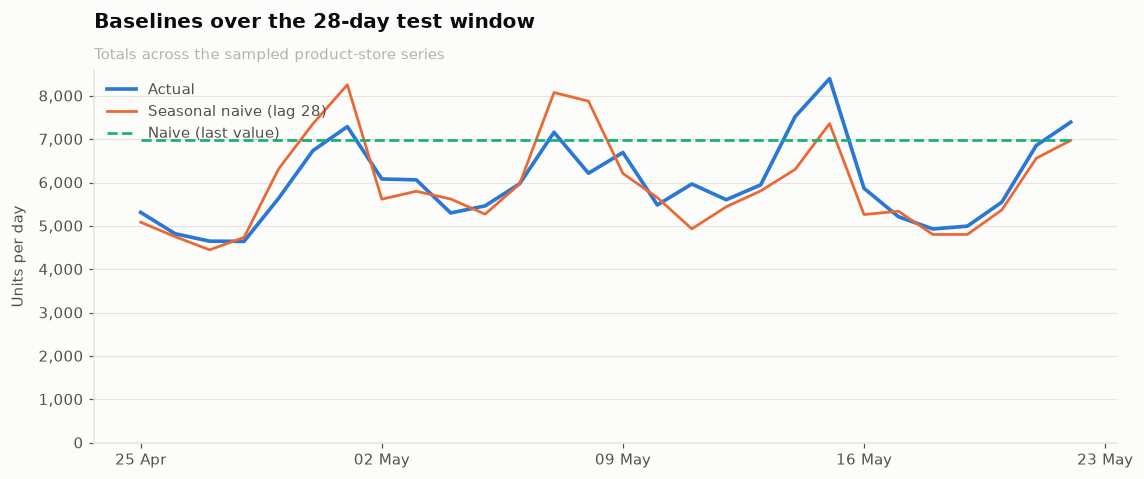

In [68]:
pred_naive = flat_naive(test_meta, TEST_START)
pred_snaive = X_test["lag_28"].to_numpy()

agg = (test_meta.assign(naive=pred_naive, snaive=pred_snaive)
                .groupby("date", observed=True)[["sales", "naive", "snaive"]].sum())

fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(agg.index, agg["sales"],  lw=2.4, color=BLUE,   label="Actual")
ax.plot(agg.index, agg["snaive"], lw=1.8, color=ORANGE, label="Seasonal naive (lag 28)")
ax.plot(agg.index, agg["naive"],  lw=1.8, color=AQUA,   ls="--", label="Naive (last value)")
finish(ax, "Baselines over the 28-day test window",
       "Totals across the sampled product-store series", ylabel="Units per day", legend=True)
ax.set_ylim(0, None)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.show()

---

# Part 5 — Machine-learning models

Built up progressively, weakest first, so each model's contribution is visible:

1. **Linear Regression** — a simple ML baseline. Tells us how much of the signal is linear.
2. **Random Forest** — bagged trees; demonstrates nonlinear relationships and interactions.
3. **XGBoost** — gradient boosting; usually the strongest traditional model on this shape of problem.
4. **LightGBM** — leaf-wise boosting with native categorical handling; the workhorse of the M5
   leaderboard, because a lag/rolling reframing turns forecasting into ordinary supervised learning on
   a large tabular dataset.

All four are trained on **`FEATURES`** (the 28-day-horizon-safe set) and validated on the same 28-day
window, so the comparison is like-for-like. Predictions are clipped at zero — negative unit sales do
not exist.

In [69]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

results = []          # collected scores from every model
predictions = {}      # test-window predictions, for the final chart

def record(name, model_val_pred, model_test_pred, seconds):
    results.append({**evaluate(y_val,  model_val_pred,  name), "split": "validation",
                    "fit_seconds": round(seconds, 1)})
    results.append({**evaluate(y_test, model_test_pred, name), "split": "test",
                    "fit_seconds": round(seconds, 1)})
    predictions[name] = np.clip(model_test_pred, 0, None)
    print(pd.DataFrame(results[-2:]).set_index(["split", "model"]).round(4).to_string())

print(f"training rows: {len(X_train):,} | features: {len(FEATURES)}")

training rows: 3,209,516 | features: 25


## 5.1 Model 1 — Linear Regression

A linear model cannot use an integer `store_code` sensibly (it would read store 7 as "seven times
store 1"), so the low-cardinality identity and calendar columns are one-hot encoded and the numeric
columns are standardised. `item_code` is left out — 400 dummies would dominate the design matrix
without telling a linear model anything it can use.

Fitted on a 1M-row subsample: `LinearRegression` solves the normal equations on a dense `float64`
array, and the full 3M x 60 matrix does not fit comfortably in 8 GB. Trees below use all the rows.

In [70]:
LR_ONEHOT  = ["dept_code", "cat_code", "store_code", "state_code",
              "day_of_week", "month", "quarter", "event_type_code"]
LR_NUMERIC = [f for f in FEATURES if f not in LR_ONEHOT + ["item_code"]]

lr = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype="float32"),
         LR_ONEHOT),
        ("num", StandardScaler(), LR_NUMERIC),
    ])),
    ("model", LinearRegression()),
])

LR_SAMPLE = 1_000_000
rs = np.random.default_rng(RANDOM_STATE)
sub = rs.choice(len(X_train), size=min(LR_SAMPLE, len(X_train)), replace=False)

t0 = time.time()
lr.fit(X_train.iloc[sub][FEATURES], y_train.iloc[sub])
lr_secs = time.time() - t0
print(f"fitted on {len(sub):,} rows in {lr_secs:.1f}s")

record("Linear Regression", lr.predict(X_val[FEATURES]), lr.predict(X_test[FEATURES]), lr_secs)

fitted on 1,000,000 rows in 8.8s
                                 MAE    RMSE  MAPE_nonzero_%  WMAPE_%  fit_seconds
split      model                                                                  
validation Linear Regression  1.1766  2.5859         55.7336  79.3785          8.8
test       Linear Regression  1.1372  2.5266         57.4400  75.9118          8.8


## 5.2 Model 2 — Random Forest

Bagged decision trees: nonlinear, captures interactions (e.g. *weekend* **and** *on promotion* **and**
*FOODS*) that the linear model cannot express, and needs no scaling or encoding.

Random Forests grow trees to purity and hold every one in memory, so this is the most expensive model
per unit of accuracy here. It is fitted on a 600k-row subsample with a depth cap — a deliberate
constraint, and the reason it is a stepping stone rather than the final answer.

In [71]:
RF_SAMPLE = 600_000
sub_rf = rs.choice(len(X_train), size=min(RF_SAMPLE, len(X_train)), replace=False)

rf = RandomForestRegressor(
    n_estimators=80, max_depth=16, min_samples_leaf=25,
    max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE,
)

t0 = time.time()
rf.fit(X_train.iloc[sub_rf][FEATURES].to_numpy(dtype="float32"), y_train.iloc[sub_rf])
rf_secs = time.time() - t0
print(f"fitted {rf.n_estimators} trees on {len(sub_rf):,} rows in {rf_secs:.1f}s")

record("Random Forest",
       rf.predict(X_val[FEATURES].to_numpy(dtype="float32")),
       rf.predict(X_test[FEATURES].to_numpy(dtype="float32")), rf_secs)

fitted 80 trees on 600,000 rows in 79.1s
                             MAE    RMSE  MAPE_nonzero_%  WMAPE_%  fit_seconds
split      model                                                              
validation Random Forest  1.1464  2.5167         57.3662  77.3419         79.1
test       Random Forest  1.1400  2.4827         58.0739  76.0975         79.1


## 5.3 Model 3 — XGBoost

Gradient boosting: trees fitted **sequentially**, each one correcting the residual of the ensemble so
far. `tree_method="hist"` buckets the features so it scales to millions of rows on CPU.

The number of trees is chosen by **early stopping on the validation window** rather than fixed —
training stops when the held-out RMSE has not improved for 50 rounds. That makes validation part of
model selection, which is exactly why the test window has to stay untouched until the end.

In [72]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=3000, learning_rate=0.05, max_depth=8,
    min_child_weight=20, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, tree_method="hist", n_jobs=-1,
    random_state=RANDOM_STATE, early_stopping_rounds=50, eval_metric="rmse",
)

t0 = time.time()
xgb.fit(X_train[FEATURES], y_train,
        eval_set=[(X_val[FEATURES], y_val)], verbose=False)
xgb_secs = time.time() - t0
print(f"best iteration: {xgb.best_iteration} of 3000 | {xgb_secs:.1f}s")

record("XGBoost", xgb.predict(X_val[FEATURES]), xgb.predict(X_test[FEATURES]), xgb_secs)

best iteration: 108 of 3000 | 68.3s
                       MAE    RMSE  MAPE_nonzero_%  WMAPE_%  fit_seconds
split      model                                                        
validation XGBoost  1.1427  2.4998         57.3621  77.0918         68.3
test       XGBoost  1.1351  2.4746         57.6462  75.7736         68.3


## 5.4 Model 4 — LightGBM

LightGBM grows trees **leaf-wise** (splitting the leaf with the largest loss reduction) instead of
level-wise, which usually reaches the same accuracy in fewer, deeper trees. More importantly for this
problem it handles **categorical features natively** — `item_code` and `store_code` are partitioned
into groups rather than split on a meaningless numeric ordering.

That is the main reason LightGBM dominated the M5 leaderboard: once lag and rolling features turn
forecasting into supervised learning, this is just a very large tabular problem with high-cardinality
identity columns.

In [73]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    n_estimators=4000, learning_rate=0.05, num_leaves=128,
    min_child_samples=50, subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=-1,
)

t0 = time.time()
lgbm.fit(X_train[FEATURES], y_train,
         eval_set=[(X_val[FEATURES], y_val)], eval_metric="rmse",
         categorical_feature=CATEGORICAL_FEATURES,
         callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)])
lgb_secs = time.time() - t0
print(f"best iteration: {lgbm.best_iteration_} of 4000 | {lgb_secs:.1f}s")

record("LightGBM", lgbm.predict(X_val[FEATURES]), lgbm.predict(X_test[FEATURES]), lgb_secs)

c:\Users\Absolomjr\Desktop\Retail Sales Forecasting & Intelligence Dashboard\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[200]	valid_0's rmse: 2.44415	valid_0's l2: 5.97388
[400]	valid_0's rmse: 2.44285	valid_0's l2: 5.96749
best iteration: 305 of 4000 | 78.9s
                        MAE    RMSE  MAPE_nonzero_%  WMAPE_%  fit_seconds
split      model                                                         
validation LightGBM  1.1186  2.4351         58.2708  75.4653         78.9
test       LightGBM  1.0999  2.4404         57.6700  73.4216         78.9


## 5.5 Results

Baselines and models side by side, on the untouched 28-day test window.

In [74]:
scores = pd.concat([
    baselines.reset_index().assign(fit_seconds=np.nan),
    pd.DataFrame(results),
], ignore_index=True)

test_scores = (scores[scores["split"] == "test"]
               .set_index("model")[["MAE", "RMSE", "MAPE_nonzero_%", "WMAPE_%", "fit_seconds"]]
               .sort_values("RMSE"))
val_scores  = (scores[scores["split"] == "validation"]
               .set_index("model")[["MAE", "RMSE", "WMAPE_%"]].sort_values("RMSE"))

print("VALIDATION")
display(val_scores.round(4))
print("TEST (untouched until now)")
display(test_scores.round(4))

sn = test_scores.loc["Seasonal naive (lag 28)"]
best = test_scores.index[0]
print(f"\nbest model on test: {best}")
print(f"RMSE {test_scores.loc[best, 'RMSE']:.4f} vs seasonal naive {sn['RMSE']:.4f} "
      f"-> {1 - test_scores.loc[best, 'RMSE'] / sn['RMSE']:+.1%}")
print(f"MAE  {test_scores.loc[best, 'MAE']:.4f} vs seasonal naive {sn['MAE']:.4f} "
      f"-> {1 - test_scores.loc[best, 'MAE'] / sn['MAE']:+.1%}")

VALIDATION


,MAE,RMSE,WMAPE_%
model,,,
LightGBM,1.1186,2.4351,75.4653
XGBoost,1.1427,2.4998,77.0918
Random Forest,1.1464,2.5167,77.3419
Linear Regression,1.1766,2.5859,79.3785
Seasonal naive (lag 28),1.3556,3.1776,91.4497
Naive (last value),1.4344,3.5452,96.7666


TEST (untouched until now)


,MAE,RMSE,MAPE_nonzero_%,WMAPE_%,fit_seconds
model,,,,,
LightGBM,1.0999,2.4404,57.6700,73.4216,78.9
XGBoost,1.1351,2.4746,57.6462,75.7736,68.3
Random Forest,1.1400,2.4827,58.0739,76.0975,79.1
Linear Regression,1.1372,2.5266,57.4400,75.9118,8.8
Naive (last value),1.4387,3.1231,91.7482,96.0377,NaN
Seasonal naive (lag 28),1.3630,3.1958,87.2705,90.9846,NaN



best model on test: LightGBM
RMSE 2.4404 vs seasonal naive 3.1958 -> +23.6%
MAE  1.0999 vs seasonal naive 1.3630 -> +19.3%


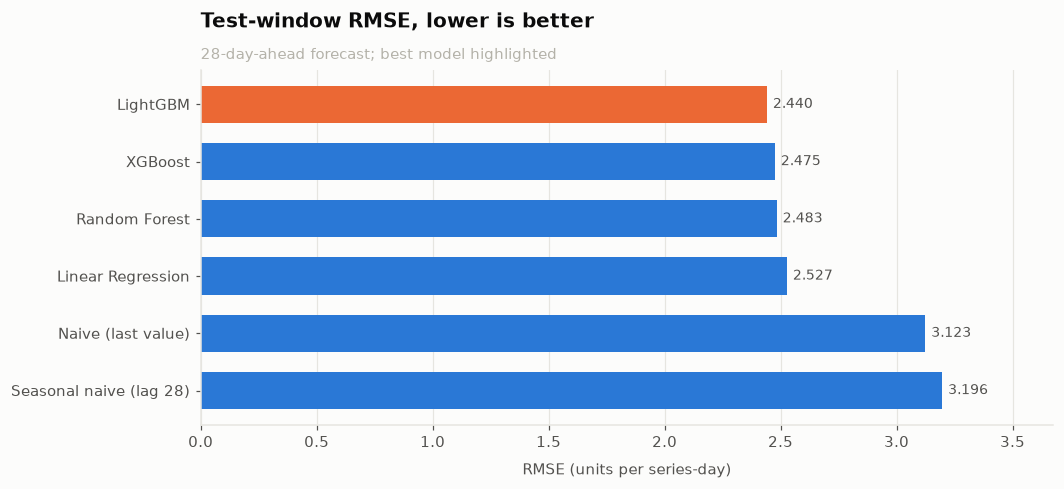

In [75]:
order = test_scores.sort_values("RMSE", ascending=True).index.tolist()[::-1]
vals  = test_scores.loc[order, "RMSE"]
colours = [ORANGE if m == order[-1] else BLUE for m in order]

fig, ax = plt.subplots(figsize=(10, 4.2))
bars = ax.barh([str(m) for m in order], vals.values, color=colours, height=0.65)
ax.bar_label(bars, fmt=lambda v: f"{v:.3f}", padding=4, fontsize=9, color=INK2)
finish(ax, "Test-window RMSE, lower is better",
       "28-day-ahead forecast; best model highlighted", xlabel="RMSE (units per series-day)",
       xgrid=True, yfmt=False)
ax.set_xlim(0, vals.max() * 1.15)
plt.show()

Reading the table honestly:

* **Every model beats both baselines**, and by a wide margin — LightGBM cuts test RMSE from the
  seasonal naive's 3.196 to **2.440 (−23.6%)** and MAE from 1.363 to **1.100 (−19.3%)**. That gap is
  the whole justification for the exercise; without the baselines the 2.44 would be a number with no
  meaning.
* **The ordering is LightGBM > XGBoost > Random Forest > Linear Regression**, exactly the progression
  we expected — but note how *close* they are. Linear Regression, on a 1M-row subsample and a few seconds
  of fitting, lands within 3.5% of LightGBM's RMSE. Most of the signal in this problem is in the
  features, not the model class.
* **Validation and test agree** on the ranking, which is the check that matters: had they disagreed,
  it would mean the early stopping had overfitted the validation window.
* **MAPE is the odd one out** — Linear Regression has the *best* MAPE on non-zero actuals while having
  the worst RMSE. That is the metric doing what §4 warned about: computed on a 46.5% subset of rows,
  it measures something different from the other three columns. WMAPE is the percentage to quote.

## 5.6 What the best model learned

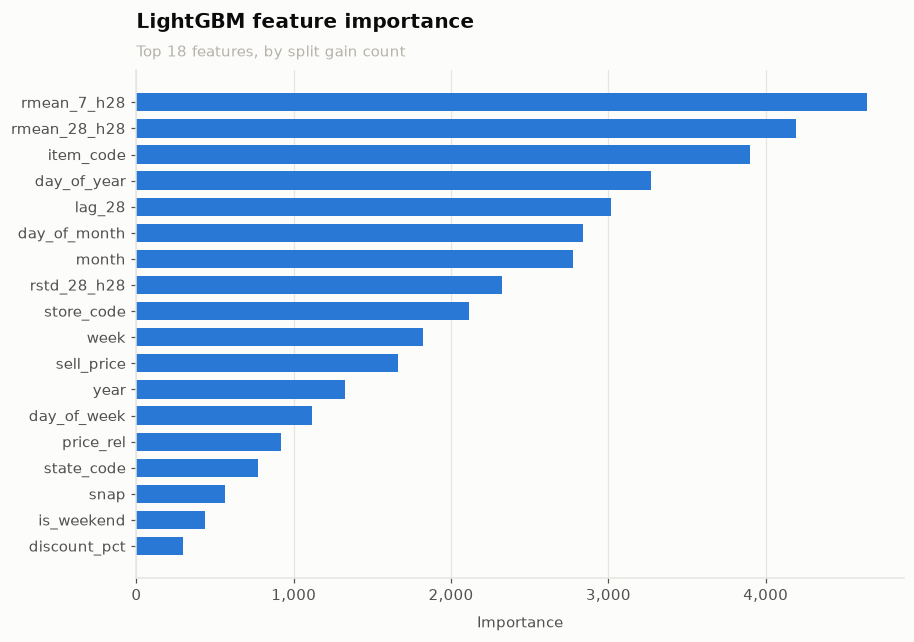

In [76]:
imp = (pd.Series(lgbm.feature_importances_, index=FEATURES)
         .sort_values(ascending=False).head(18).iloc[::-1])

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(imp.index, imp.values, color=BLUE, height=0.7)
finish(ax, "LightGBM feature importance", "Top 18 features, by split gain count",
       xlabel="Importance", xgrid=True)
plt.show()

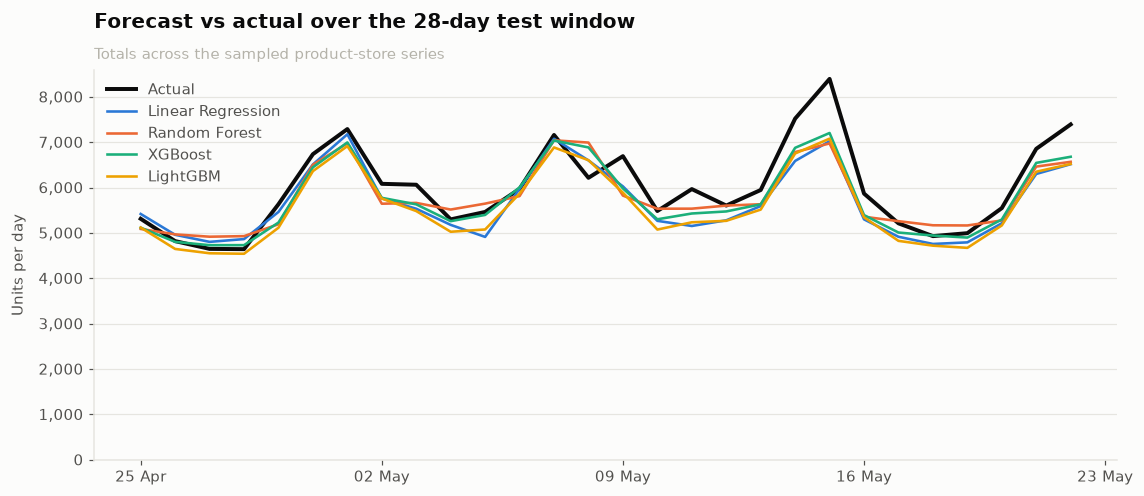

In [77]:
plot_df = test_meta.copy()
for name, pred in predictions.items():
    plot_df[name] = pred
agg = plot_df.groupby("date", observed=True)[["sales"] + list(predictions)].sum()

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(agg.index, agg["sales"], lw=2.6, color=INK, label="Actual")
for i, name in enumerate(predictions):
    ax.plot(agg.index, agg[name], lw=1.7, color=SERIES[i % 8], label=name)
finish(ax, "Forecast vs actual over the 28-day test window",
       "Totals across the sampled product-store series", ylabel="Units per day", legend=True)
ax.set_ylim(0, None)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.show()

## 5.7 How much would leakage have flattered us?

The same LightGBM, same hyper-parameters, trained on **`FEATURES_ALL`** — which adds `lag_1`, `lag_7`,
`lag_14` and the `shift(1)` rolling windows.

Those features are legitimate for a **next-day** forecast that is re-run every night. They are **not**
available for a 28-day-ahead forecast: on the last day of the window, `lag_1` is a value from 27 days
into the future.

The gap between the two rows below is the number to keep in mind. It is what you would report if you
did not think carefully about the horizon, and it is not achievable in production.

In [78]:
lgbm_leaky = lgb.LGBMRegressor(
    n_estimators=4000, learning_rate=0.05, num_leaves=128,
    min_child_samples=50, subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=-1,
)
t0 = time.time()
lgbm_leaky.fit(X_train[FEATURES_ALL], y_train,
               eval_set=[(X_val[FEATURES_ALL], y_val)], eval_metric="rmse",
               categorical_feature=CATEGORICAL_FEATURES,
               callbacks=[lgb.early_stopping(100, verbose=False)])
leaky_secs = time.time() - t0

leaky_test = evaluate(y_test, lgbm_leaky.predict(X_test[FEATURES_ALL]),
                      "LightGBM + short-horizon lags (NOT 28-day valid)")

comparison = pd.DataFrame([
    test_scores.loc["LightGBM"].to_dict() | {"model": "LightGBM (28-day valid)"},
    leaky_test,
]).set_index("model")[["MAE", "RMSE", "WMAPE_%"]]

display(comparison.round(4))
print(f"apparent RMSE improvement from short-horizon lags: "
      f"{1 - comparison.iloc[1]['RMSE'] / comparison.iloc[0]['RMSE']:+.1%}")
print("...unavailable at a 28-day horizon. Reporting it as the model's score would be leakage.")

c:\Users\Absolomjr\Desktop\Retail Sales Forecasting & Intelligence Dashboard\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


,MAE,RMSE,WMAPE_%
model,,,
LightGBM (28-day valid),1.0999,2.4404,73.4216
LightGBM + short-horizon lags (NOT 28-day valid),1.0244,2.1550,68.3840


apparent RMSE improvement from short-horizon lags: +11.7%
...unavailable at a 28-day horizon. Reporting it as the model's score would be leakage.


---

# Part 6 — From a model to a product

Part 5 finished with a number: LightGBM, test RMSE **2.44**, roughly a quarter better than the
seasonal naive. That is a *result*. It is not yet a *product*, and the distance between the two is
what this part covers.

| § | Question | Why it has to be asked |
|---|---|---|
| 6.1 | Is that score luck? | One 28-day window is a single draw. Four rolling origins are four draws. |
| 6.2 | What would the M5 have scored it? | RMSE treats a 400-units-a-day series and a 0.1-units-a-day series as equally important. WRMSSE does not. |
| 6.3 | *Where* is it wrong? | An average error hides which products, which days and which volumes it is made of. |
| 6.4 | Can it be better? | Optuna over the LightGBM space — tuned on validation, never on test. |
| 6.5 | Direct or recursive? | The other way to forecast 28 days, and what it costs. |
| 6.6 | Which one ships? | Every candidate, both baselines, both metrics, one table. |
| 6.7 | Why does it predict that? | Gain importance, SHAP, partial dependence. |
| 6.8 | Can anyone else reproduce this? | MLflow: parameters, metrics and the model itself, for every run. |
| 6.9 | Will serving match training? | One feature module, imported by both, asserted equal before anything is saved. |

Everything scored from here on uses **`FEATURES`** — the 25 columns that are knowable 28 days ahead.


## 6.1 Rolling-origin cross-validation

Part 5's test score came from one month: 25 April to 22 May 2016. If that month happened to be calm,
the score flatters the model; if it happened to be turbulent, it punishes it. Either way, a single
window cannot tell us which.

`KFold` is still not an option — shuffling rows would train on the future. The time-series equivalent
is **rolling-origin evaluation**: pick several origins, and at each one retrain from scratch on
everything before it, then score the 28 days after it.

```
fold 3   |------- train -------| val | test |
fold 2   |--------- train ---------| val | test |
fold 1   |----------- train ----------| val | test |
fold 0   |------------- train -----------| val | test |
         +--------------------------------------------> time
                                                   d_1941
```

Each fold keeps the same shape as Part 3 — a 28-day validation window for early stopping, then a
28-day test window — slid back four weeks at a time. Fold 0 *is* the Part 3 split, so its numbers
should reproduce §5.4 exactly; that is the cheapest available check that this loop does what the
earlier code did.


In [ ]:
import json
import warnings
from pathlib import Path

# Part 6 fits ~16 more models and draws ~20 more figures. Two warnings would otherwise
# repeat on every one of them and bury the output that matters.
warnings.filterwarnings("ignore", message=".*eval_set.*")
mpl.rcParams["figure.max_open_warning"] = 0

CV_FOLDS = 4

LGBM_BASE = dict(n_estimators=4000, learning_rate=0.05, num_leaves=128,
                 min_child_samples=50, subsample=0.8, subsample_freq=1,
                 colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1,
                 random_state=RANDOM_STATE, verbose=-1)


def fit_lgbm(params, Xtr, ytr, Xva, yva, stopping=100):
    """Fit a LightGBM regressor, early-stopping on the supplied validation set."""
    m = lgb.LGBMRegressor(**params)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="rmse",
          categorical_feature=CATEGORICAL_FEATURES,
          callbacks=[lgb.early_stopping(stopping, verbose=False)])
    return m


def score_only(y_true, y_pred):
    """`evaluate` without the label column."""
    d = evaluate(y_true, y_pred, "_")
    d.pop("model")
    return d


day = model_df["d_num"].to_numpy()
cv_rows = []

for k in range(CV_FOLDS):
    origin  = TEST_START - 28 * k          # first day of this fold's test window
    v_start = origin - 28                  # its validation window starts here
    tr = day < v_start
    va = (day >= v_start) & (day < origin)
    te = (day >= origin) & (day < origin + 28)

    Xtr, ytr = model_df.loc[tr, FEATURES], model_df.loc[tr, TARGET].astype("float32")
    Xva, yva = model_df.loc[va, FEATURES], model_df.loc[va, TARGET].astype("float32")
    Xte, yte = model_df.loc[te, FEATURES], model_df.loc[te, TARGET].astype("float32")

    t0 = time.time()
    m = fit_lgbm(LGBM_BASE, Xtr, ytr, Xva, yva)
    secs = time.time() - t0

    cv_rows.append({
        "fold": k,
        "test_from": model_df.loc[te, "date"].min().date(),
        "test_to":   model_df.loc[te, "date"].max().date(),
        "train_rows": int(tr.sum()),
        **score_only(yte, m.predict(Xte)),
        "naive_RMSE": score_only(yte, Xte["lag_28"])["RMSE"],
        "best_iter": int(m.best_iteration_),
        "fit_seconds": round(secs, 1),
    })
    r = cv_rows[-1]
    print(f"fold {k}  {r['test_from']} -> {r['test_to']}  "
          f"train {r['train_rows']:>9,}  RMSE {r['RMSE']:.4f}  "
          f"(naive {r['naive_RMSE']:.4f})  {secs:.0f}s")

    del m, Xtr, ytr, Xva, yva, Xte, yte
    gc.collect()

cv = pd.DataFrame(cv_rows).set_index("fold")
display(cv[["test_from", "test_to", "train_rows", "MAE", "RMSE", "WMAPE_%",
            "naive_RMSE", "best_iter", "fit_seconds"]].round(4))


In [ ]:
print(f"RMSE across {CV_FOLDS} folds : {cv['RMSE'].mean():.4f} +/- {cv['RMSE'].std():.4f}"
      f"   (min {cv['RMSE'].min():.4f}, max {cv['RMSE'].max():.4f})")
print(f"MAE  across {CV_FOLDS} folds : {cv['MAE'].mean():.4f} +/- {cv['MAE'].std():.4f}")
print(f"beats the seasonal naive in {int((cv['RMSE'] < cv['naive_RMSE']).sum())}/{CV_FOLDS} folds, "
      f"by {(1 - cv['RMSE'] / cv['naive_RMSE']).mean():.1%} on average")
print(f"\nfold 0 reproduces the Part 3 split: RMSE {cv.loc[0, 'RMSE']:.4f} "
      f"vs section 5.4's {test_scores.loc['LightGBM', 'RMSE']:.4f}")

x = np.arange(CV_FOLDS)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(x - 0.19, cv["naive_RMSE"], width=0.36, color=MUTED, label="Seasonal naive")
b = ax.bar(x + 0.19, cv["RMSE"], width=0.36, color=BLUE, label="LightGBM")
ax.bar_label(b, fmt=lambda v: f"{v:.3f}", padding=3, fontsize=9, color=INK2)
ax.axhline(cv["RMSE"].mean(), color=ORANGE, lw=1.6, ls="--", zorder=3)
ax.text(CV_FOLDS - 0.55, cv["RMSE"].mean(), f"  mean {cv['RMSE'].mean():.3f}",
        color=ORANGE, fontsize=9, va="bottom")
ax.set_xticks(x)
ax.set_xticklabels([f"fold {k}\n{cv.loc[k, 'test_from']}" for k in x], fontsize=9)
finish(ax, "Rolling-origin cross-validation",
       "Four consecutive 28-day origins, each model retrained from scratch",
       ylabel="Test RMSE", legend=True, yfmt=False)
plt.show()


## 6.2 The M5's own metric — WRMSSE

RMSE in units has a blind spot that this dataset makes severe. `FOODS_3_090` sells hundreds of units a
day; a slow HOBBIES item sells one a fortnight. A squared error of 4 means something very different in
each case, and RMSE adds them together as though it did not.

The M5 competition scored on **WRMSSE**, which fixes both halves of that problem. For each series *i*:

```
                 sqrt(  mean over the horizon of (actual - predicted)^2  )
    RMSSE_i  =   ---------------------------------------------------------
                 sqrt(  mean over its own history of (y_t - y_{t-1})^2   )

    WRMSSE   =   sum over series of  w_i * RMSSE_i
```

* The **denominator** is the error a one-step naive forecast would have made on that series' own
  training history. It puts every series on the same axis: **RMSSE = 1 means "no better than repeating
  yesterday's number"**, and below 1 is genuinely useful.
* The **weight** `w_i` is the series' share of dollar sales over the last 28 days of training. An error
  on a product nobody buys should not count as much as the same error on a bestseller.

Following the competition, the scale is computed from each series' first non-zero sale onwards —
counting the years before a product was ever stocked would make the denominator meaninglessly small.


In [ ]:
SERIES_ID = ["item_id", "store_id"]


def m5_scale(train: pd.DataFrame) -> pd.Series:
    """Mean squared one-step naive error per series, from its first non-zero sale."""
    out = {}
    for key, g in train.sort_values("d_num").groupby(SERIES_ID, observed=True, sort=False):
        s = g["sales"].to_numpy(dtype="float64")
        nz = np.flatnonzero(s > 0)
        if nz.size == 0:
            continue                       # never sold: no scale can be defined
        s = s[nz[0]:]
        if s.size < 2:
            continue
        out[key] = float((np.diff(s) ** 2).mean())
    return pd.Series(out, name="scale").rename_axis(SERIES_ID)


def m5_weights(train: pd.DataFrame, days: int = 28) -> pd.Series:
    """Each series' share of dollar sales over the last `days` of training."""
    recent = train[train["d_num"] > train["d_num"].max() - days]
    rev = (recent.assign(_rev=recent["sales"] * recent["sell_price"])
                 .groupby(SERIES_ID, observed=True)["_rev"].sum())
    return (rev / rev.sum()).rename("weight")


train_rows = model_df.loc[is_train, SERIES_ID + ["d_num", "sales", "sell_price"]]
scale   = m5_scale(train_rows)
weights = m5_weights(train_rows)
print(f"scales defined for {len(scale):,} of "
      f"{model_df.groupby(SERIES_ID, observed=True).ngroups:,} series")
del train_rows
gc.collect()


def wrmsse(meta: pd.DataFrame, y_pred) -> tuple[float, pd.DataFrame]:
    """Weighted RMSSE over one evaluation window, plus the per-series detail."""
    d = meta[SERIES_ID].copy()
    d["sq"] = (np.clip(np.asarray(y_pred, dtype="float64"), 0, None)
               - meta["sales"].to_numpy(dtype="float64")) ** 2
    per = d.groupby(SERIES_ID, observed=True)["sq"].mean().to_frame("mse")
    per = per.join(scale, how="inner").join(weights, how="inner")
    per = per[per["scale"] > 0].copy()
    per["rmsse"] = np.sqrt(per["mse"] / per["scale"])
    per["weight"] = per["weight"] / per["weight"].sum()      # renormalise over scored series
    return float((per["weight"] * per["rmsse"]).sum()), per


In [ ]:
wr_rows = []
for name, pred in predictions.items():
    wr_rows.append({"model": name, "WRMSSE": wrmsse(test_meta, pred)[0]})
wr_rows.append({"model": "Seasonal naive (lag 28)",
                "WRMSSE": wrmsse(test_meta, X_test["lag_28"])[0]})
wr_rows.append({"model": "Naive (last value)",
                "WRMSSE": wrmsse(test_meta, flat_naive(test_meta, TEST_START))[0]})

wrmsse_table = pd.DataFrame(wr_rows).set_index("model").sort_values("WRMSSE")
display(wrmsse_table.round(4))

best_wrmsse_model = wrmsse_table.index[0]
best_wrmsse, per_series = wrmsse(test_meta, predictions[best_wrmsse_model])
print(f"best on WRMSSE: {best_wrmsse_model} = {best_wrmsse:.4f}")
print(f"dollar weight held by series forecast better than a one-step naive (RMSSE < 1): "
      f"{per_series.loc[per_series['rmsse'] < 1, 'weight'].sum():.1%}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))

ax = axes[0]
ax.hist(per_series["rmsse"].clip(0, 3), bins=48, color=BLUE, alpha=0.85)
top = ax.get_ylim()[1]
ax.axvline(1.0, color=INK, lw=1.6, ls="--")
ax.text(1.04, top * 0.95, "RMSSE = 1\nno better than\nrepeating yesterday",
        fontsize=8.5, color=INK2, va="top")
ax.axvline(best_wrmsse, color=ORANGE, lw=1.8)
ax.text(best_wrmsse, top * 0.42, f" weighted\n mean {best_wrmsse:.2f}", fontsize=8.5, color=ORANGE)
finish(ax, "RMSSE per series", f"{len(per_series):,} series, clipped at 3",
       xlabel="RMSSE", ylabel="Series")

ax = axes[1]
ax.scatter(per_series["weight"] * 100, per_series["rmsse"], s=9, alpha=0.4, color=BLUE)
ax.axhline(1.0, color=INK, lw=1.4, ls="--")
ax.set_xscale("log")
finish(ax, "Where the weight sits",
       "Dollar weight against accuracy; the right-hand points decide the score",
       xlabel="Series weight (% of dollar sales, log scale)", ylabel="RMSSE", yfmt=False)
ax.set_ylim(0, 3)
plt.tight_layout()
plt.show()


## 6.3 Error analysis — where is it wrong?

A single RMSE is an average over 112,000 predictions, and averages conceal. Four cuts are worth
making, each of which could change what you do next:

1. **By horizon day.** This is a *direct* model: one estimator predicts all 28 days at once. If
   accuracy decayed sharply from day 1 to day 28, the framing would be under-powered and a
   per-horizon model would be the fix.
2. **By category.** If one category is much worse, it may need its own model — or its own features.
3. **By series volume.** Errors on fast movers cost money; errors on slow movers are mostly zeros.
4. **Calibration and bias.** Does the model systematically over- or under-predict, and where?


In [ ]:
ERR_MODEL = "LightGBM"

err = test_meta.copy()
err["pred"] = np.clip(predictions[ERR_MODEL], 0, None)
err["error"] = err["pred"] - err["sales"]
err["horizon_day"] = err["d_num"] - TEST_START + 1
err["cat_id"] = model_df.loc[is_test, "cat_id"].to_numpy()

# series volume, measured on training data only
vol = (model_df.loc[is_train].groupby(SERIES_ID, observed=True)["sales"].mean()
       .rename("train_daily_units"))
err = err.merge(vol, on=SERIES_ID, how="left")
err["volume_decile"] = pd.qcut(err["train_daily_units"].rank(method="first"),
                               10, labels=range(1, 11)).astype(int)

by_horizon = err.groupby("horizon_day").apply(
    lambda g: pd.Series(score_only(g["sales"], g["pred"])), include_groups=False)
by_cat = err.groupby("cat_id", observed=True).apply(
    lambda g: pd.Series({**score_only(g["sales"], g["pred"]),
                         "bias": g["error"].mean(), "rows": float(len(g))}),
    include_groups=False)
by_vol = err.groupby("volume_decile").apply(
    lambda g: pd.Series({**score_only(g["sales"], g["pred"]),
                         "mean_units": g["sales"].mean(), "bias": g["error"].mean()}),
    include_groups=False)

print("BY CATEGORY")
display(by_cat.round(4))
print("BY VOLUME DECILE (1 = slowest tenth of series)")
display(by_vol.round(4))
print(f"overall bias (mean predicted - actual): {err['error'].mean():+.4f} units per series-day")
print(f"day 1 RMSE {by_horizon.loc[1, 'RMSE']:.4f}  ->  day 28 RMSE {by_horizon.loc[28, 'RMSE']:.4f}"
      f"   ({by_horizon.loc[28, 'RMSE'] / by_horizon.loc[1, 'RMSE'] - 1:+.1%})")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.1))

ax = axes[0]
ax.plot(by_horizon.index, by_horizon["RMSE"], color=BLUE, marker="o", ms=3.5)
z = np.polyfit(by_horizon.index, by_horizon["RMSE"], 1)
ax.plot(by_horizon.index, np.poly1d(z)(by_horizon.index), color=ORANGE, lw=1.4, ls="--",
        label=f"trend {z[0]:+.4f} RMSE/day")
finish(ax, "Accuracy across the horizon", "One estimator predicts every day of the window",
       xlabel="Days ahead", ylabel="RMSE", legend=True, yfmt=False)

ax = axes[1]
ax.barh([str(i) for i in by_vol.index], by_vol["WMAPE_%"], color=BLUE, height=0.7)
finish(ax, "Error by series volume", "Deciles of average training units per day",
       xlabel="WMAPE (%)", ylabel="Volume decile", xgrid=True, yfmt=False)

ax = axes[2]
cal_df = (err.assign(bucket=pd.cut(err["pred"], [-.01, .5, 1, 2, 4, 8, 16, 32, 1e9]))
             .groupby("bucket", observed=True)[["pred", "sales"]].mean())
ax.plot(cal_df["pred"], cal_df["sales"], color=BLUE, marker="o", ms=5)
lim = float(max(cal_df.max())) * 1.08
ax.plot([0, lim], [0, lim], color=MUTED, lw=1.3, ls="--")
ax.text(lim * 0.5, lim * 0.93, "perfect calibration", color=MUTED, fontsize=8.5)
finish(ax, "Calibration", "Mean actual against mean predicted, by prediction bucket",
       xlabel="Predicted units", ylabel="Actual units", yfmt=False)

plt.tight_layout()
plt.show()


## 6.4 Hyper-parameter tuning with Optuna

Part 5's LightGBM used hand-picked hyper-parameters. They were reasonable, not optimal, and the honest
way to improve them is a search that never sees the test window.

**Optuna** runs a Tree-structured Parzen Estimator: rather than trying every combination (grid search)
or random ones (random search), it models which regions of the space have produced low scores and
concentrates its remaining trials there. On a search this size that is worth several plain random
trials.

Two rules keep this from becoming a leak:

* every trial is scored on the **validation** window, never on test;
* the test window is touched exactly once afterwards, to report a number.

The consequence — worth stating before the result rather than after — is that **the tuned model may
well score slightly worse on test than the untuned one**. That is not a bug. Selecting on validation
is what you can do in real life; selecting on test is what makes a backtest lie.


In [ ]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 10

X_tr_f, X_va_f, X_te_f = X_train[FEATURES], X_val[FEATURES], X_test[FEATURES]


def objective(trial: "optuna.Trial") -> float:
    params = dict(LGBM_BASE)
    params.update(
        n_estimators=2000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
        num_leaves=trial.suggest_int("num_leaves", 31, 255),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    )
    m = fit_lgbm(params, X_tr_f, y_train, X_va_f, y_val, stopping=50)
    rmse = score_only(y_val, m.predict(X_va_f))["RMSE"]
    trial.set_user_attr("best_iteration", int(m.best_iteration_))
    del m
    gc.collect()
    return rmse


study = optuna.create_study(direction="minimize", study_name="lgbm-28d-direct",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
search_secs = time.time() - t0

trials = (study.trials_dataframe(attrs=("number", "value", "params", "duration"))
          .rename(columns=lambda c: c.replace("params_", "")))
display(trials.sort_values("value").round(5))
print(f"{N_TRIALS} trials in {search_secs/60:.1f} min")
print(f"best validation RMSE {study.best_value:.5f} "
      f"(baseline LightGBM {val_scores.loc['LightGBM', 'RMSE']:.5f}, "
      f"{1 - study.best_value / val_scores.loc['LightGBM', 'RMSE']:+.2%})")
print("best params:", json.dumps(study.best_params, indent=2))


In [ ]:
BEST_PARAMS = {**LGBM_BASE, **study.best_params}

t0 = time.time()
lgbm_tuned = fit_lgbm(BEST_PARAMS, X_tr_f, y_train, X_va_f, y_val, stopping=100)
tuned_secs = time.time() - t0
print(f"best iteration: {lgbm_tuned.best_iteration_} of {BEST_PARAMS['n_estimators']} "
      f"| {tuned_secs:.1f}s")

record("LightGBM (tuned)", lgbm_tuned.predict(X_va_f), lgbm_tuned.predict(X_te_f), tuned_secs)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

ax = axes[0]
running = trials.sort_values("number")["value"].cummin()
ax.plot(trials.sort_values("number")["number"], trials.sort_values("number")["value"],
        "o", ms=6, color=MUTED, label="trial")
ax.plot(running.index, running.values, color=BLUE, lw=2, label="best so far")
ax.axhline(val_scores.loc["LightGBM", "RMSE"], color=ORANGE, lw=1.5, ls="--",
           label="hand-picked params")
finish(ax, "Optuna search", f"{N_TRIALS} TPE trials, scored on the validation window",
       xlabel="Trial", ylabel="Validation RMSE", legend=True, yfmt=False)

ax = axes[1]
imp = (trials[list(study.best_params)].corrwith(trials["value"]).abs()
       .sort_values().rename("|corr with RMSE|"))
ax.barh(imp.index, imp.values, color=BLUE, height=0.68)
finish(ax, "Which hyper-parameter mattered",
       "Absolute correlation with validation RMSE across the trials",
       xlabel="|correlation|", xgrid=True, yfmt=False)

plt.tight_layout()
plt.show()


## 6.5 Direct or recursive?

There are two ways to forecast 28 days ahead, and the choice is the single most consequential
modelling decision in this project.

**Direct** — one model, trained to predict *the value 28 days out* from features that are all knowable
28 days in advance. That is what `FEATURES` encodes and what every number so far has used. It can
never use `lag_1`, because on the last day of the window `lag_1` lies four weeks in the future.

**Recursive** — one *short-horizon* model that predicts tomorrow, then is fed its own prediction as
tomorrow's `lag_1` and asked for the day after, twenty-eight times. This is how the richer
`FEATURES_ALL` set can be used at a 28-day horizon at all.

Recursive sounds strictly better — it gets to use the strong short-horizon lags. The catch is that from
day 2 onwards those lags are **predictions, not observations**, and each day's error is baked into the
next day's inputs. Error compounds.

The experiment below runs all three on the same test window:

| | Uses | Achievable in production? |
|---|---|---|
| **Direct** | `FEATURES`, actual `lag_28` | **yes** — this is the shipped model |
| **Recursive** | `FEATURES_ALL`, its own predictions as lags | **yes** |
| **Oracle lags** | `FEATURES_ALL`, *actual* `lag_1`…`lag_14` | **no** — this is §5.7's leaky score |

The third row is not a candidate. It is the ceiling the recursive model is chasing, and the gap between
rows two and three is the price of not having observed the future.


In [ ]:
# A (series x day) matrix of actual units, taken straight from the wide sales file so
# that it includes the not-stocked days that `model_df` dropped: the lags in section 2.4
# were built before that drop, and count calendar days, not surviving rows.
REC_START = TEST_START - 56
rec_day_cols = [f"d_{d}" for d in range(REC_START, LAST_DAY + 1)]

rec = sales.loc[sales["item_id"].isin(sampled_items),
                ["item_id", "store_id"] + rec_day_cols].copy()
rec["item_id"] = rec["item_id"].astype(str)
rec["store_id"] = rec["store_id"].astype(str)

S_actual = rec[rec_day_cols].to_numpy(dtype="float32")
row_of = {k: i for i, k in enumerate(zip(rec["item_id"], rec["store_id"]))}
test_row = np.array([row_of[(i, s)] for i, s in
                     zip(test_meta["item_id"].astype(str), test_meta["store_id"].astype(str))])
print(f"recursion matrix: {S_actual.shape[0]:,} series x {S_actual.shape[1]} days "
      f"(d_{REC_START} -> d_{LAST_DAY})")


In [ ]:
S = S_actual.copy()                     # predictions will overwrite the test-window columns
test_days = test_meta["d_num"].to_numpy()
rec_pred = np.zeros(len(test_meta), dtype="float64")

t0 = time.time()
for t in range(TEST_START, LAST_DAY + 1):
    pos = np.flatnonzero(test_days == t)
    if pos.size == 0:
        continue
    r = test_row[pos]
    c = t - REC_START

    Xd = X_test.iloc[pos].copy()
    for L in [1, 7, 14, 28]:
        Xd[f"lag_{L}"] = S[r, c - L]
    for W in [7, 14, 28]:
        Xd[f"rmean_{W}"] = S[r, c - W:c].mean(axis=1)
    for W in [7, 28]:
        Xd[f"rstd_{W}"] = S[r, c - W:c].std(axis=1, ddof=1)
    # windows that end 28 days back are identical either way, but recompute them from the
    # same matrix so the whole feature vector comes from one source
    Xd["rmean_7_h28"]  = S[r, c - 34:c - 27].mean(axis=1)
    Xd["rmean_28_h28"] = S[r, c - 55:c - 27].mean(axis=1)
    Xd["rstd_28_h28"]  = S[r, c - 55:c - 27].std(axis=1, ddof=1)

    p = np.clip(lgbm_leaky.predict(Xd[FEATURES_ALL]), 0, None)
    S[r, c] = p.astype("float32")          # <- tomorrow's lag_1 is today's guess
    rec_pred[pos] = p

print(f"28 recursive steps in {time.time() - t0:.1f}s")

oracle_pred = np.clip(lgbm_leaky.predict(X_test[FEATURES_ALL]), 0, None)
direct_pred = predictions["LightGBM"]

strategy = pd.DataFrame([
    {**evaluate(y_test, direct_pred,  "Direct 28-day (shipped)"),   "achievable": "yes"},
    {**evaluate(y_test, rec_pred,     "Recursive short-horizon"),   "achievable": "yes"},
    {**evaluate(y_test, oracle_pred,  "Short-horizon, oracle lags"), "achievable": "NO"},
]).set_index("model")
display(strategy.round(4))


In [ ]:
h = test_days - TEST_START + 1
curves = {"Direct 28-day (shipped)": direct_pred,
          "Recursive short-horizon": rec_pred,
          "Short-horizon, oracle lags": oracle_pred}

by_day = pd.DataFrame({
    name: [score_only(y_test.to_numpy()[h == d], np.asarray(p)[h == d])["RMSE"]
           for d in range(1, 29)]
    for name, p in curves.items()}, index=range(1, 29))

fig, ax = plt.subplots(figsize=(11.5, 4.6))
for i, (name, col) in enumerate(by_day.items()):
    ls = ":" if "oracle" in name else "-"
    ax.plot(by_day.index, col, color=SERIES[i], lw=2.1, ls=ls, marker="o", ms=3, label=name)
ax.fill_between(by_day.index, by_day.iloc[:, 2], by_day.iloc[:, 1],
                color=MUTED, alpha=0.13, zorder=0)
finish(ax, "Error compounding: direct against recursive",
       "RMSE at each day of the 28-day horizon, same test window",
       xlabel="Days ahead", ylabel="RMSE", legend=True, yfmt=False)
plt.show()

print(f"recursive RMSE, day 1  : {by_day.iloc[0, 1]:.4f}")
print(f"recursive RMSE, day 28 : {by_day.iloc[27, 1]:.4f}  "
      f"({by_day.iloc[27, 1] / by_day.iloc[0, 1] - 1:+.1%} over the horizon)")
print(f"direct    RMSE, day 1  : {by_day.iloc[0, 0]:.4f}")
print(f"direct    RMSE, day 28 : {by_day.iloc[27, 0]:.4f}  "
       f"({by_day.iloc[27, 0] / by_day.iloc[0, 0] - 1:+.1%} over the horizon)")

del S, S_actual, rec
_ = gc.collect()


## 6.6 The final scoreboard

Every candidate, both baselines, and the two metrics that matter — on the 28-day window that was held
out from the beginning and used exactly once.


In [ ]:
scores = pd.concat([baselines.reset_index().assign(fit_seconds=np.nan),
                    pd.DataFrame(results)], ignore_index=True)

val_scores = (scores[scores["split"] == "validation"]
              .set_index("model")[["MAE", "RMSE", "WMAPE_%"]].sort_values("RMSE"))
test_scores = (scores[scores["split"] == "test"]
               .set_index("model")[["MAE", "RMSE", "MAPE_nonzero_%", "WMAPE_%", "fit_seconds"]]
               .sort_values("RMSE"))

# The tuned model joined the field after 6.2, so score whatever is not yet scored.
for _name, _pred in predictions.items():
    if _name not in wrmsse_table.index:
        wrmsse_table.loc[_name, "WRMSSE"] = wrmsse(test_meta, _pred)[0]
wrmsse_table = wrmsse_table.sort_values("WRMSSE")

board = test_scores.join(wrmsse_table).join(
    val_scores["RMSE"].rename("val_RMSE")).sort_values("val_RMSE")

print("SELECTION (validation RMSE — the only score a model may be chosen on)")
display(val_scores.round(4))
print("FINAL TEST WINDOW  2016-04-25 -> 2016-05-22, used once")
display(board.round(4))

SELECTED = val_scores.index[0]

# The API hands the model a DataFrame of named columns. Random Forest was fitted on a
# bare float32 array and would not round-trip that way, so if it ever won on validation
# the next-best estimator that does is what actually ships -- said out loud rather than
# silently.
SERVABLE = ("Linear Regression", "XGBoost", "LightGBM", "LightGBM (tuned)")
SHIPPED = SELECTED if SELECTED in SERVABLE else next(
    m for m in val_scores.index if m in SERVABLE)
if SHIPPED != SELECTED:
    print(f"note: {SELECTED} won on validation but is not servable as-is; shipping {SHIPPED}\n")

sn_rmse = float(test_scores.loc["Seasonal naive (lag 28)", "RMSE"])
print(f"selected on validation RMSE: {SELECTED}")
print(f"  test RMSE   {test_scores.loc[SELECTED, 'RMSE']:.4f}  "
      f"vs seasonal naive {sn_rmse:.4f}  -> {1 - test_scores.loc[SELECTED, 'RMSE'] / sn_rmse:+.1%}")
print(f"  test MAE    {test_scores.loc[SELECTED, 'MAE']:.4f}")
print(f"  test WMAPE  {test_scores.loc[SELECTED, 'WMAPE_%']:.2f}%")
print(f"  test WRMSSE {float(wrmsse_table.loc[SELECTED, 'WRMSSE']):.4f}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

ax = axes[0]
order = board.sort_values("RMSE", ascending=False)
cols = [ORANGE if m == SELECTED else (MUTED if "aive" in str(m) else BLUE) for m in order.index]
bars = ax.barh([str(m) for m in order.index], order["RMSE"], color=cols, height=0.66)
ax.bar_label(bars, fmt=lambda v: f"{v:.3f}", padding=4, fontsize=9, color=INK2)
finish(ax, "Test RMSE, lower is better",
       "Baselines in grey, selected model in orange", xlabel="RMSE (units per series-day)",
       xgrid=True, yfmt=False)
ax.set_xlim(0, order["RMSE"].max() * 1.16)

ax = axes[1]
plot_df = test_meta.copy()
plot_df["Actual"] = plot_df["sales"]
plot_df[SELECTED] = np.clip(predictions[SELECTED], 0, None)
plot_df["Seasonal naive"] = np.clip(X_test["lag_28"].to_numpy(), 0, None)
agg = plot_df.groupby("date", observed=True)[["Actual", SELECTED, "Seasonal naive"]].sum()

ax.plot(agg.index, agg["Actual"], lw=2.7, color=INK, label="Actual")
ax.plot(agg.index, agg[SELECTED], lw=2.0, color=ORANGE, label=SELECTED)
ax.plot(agg.index, agg["Seasonal naive"], lw=1.5, color=MUTED, ls="--", label="Seasonal naive")
finish(ax, "Actual against predicted", "Daily totals across the 4,000 sampled series",
       ylabel="Units per day", legend=True)
ax.set_ylim(0, None)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

plt.tight_layout()
plt.show()


In [ ]:
# Four individual series, from the busiest to the quietest, so the aggregate above
# cannot hide what a single product-store forecast actually looks like.
vol_rank = (test_meta.groupby(SERIES_ID, observed=True)["sales"].sum()
            .sort_values(ascending=False))
picks = [vol_rank.index[0], vol_rank.index[len(vol_rank) // 20],
         vol_rank.index[len(vol_rank) // 4], vol_rank.index[len(vol_rank) // 2]]

show = test_meta.copy()
show["pred"] = np.clip(predictions[SELECTED], 0, None)

fig, axes = plt.subplots(2, 2, figsize=(13.5, 7))
for ax, (item, store) in zip(axes.ravel(), picks):
    g = show[(show["item_id"] == item) & (show["store_id"] == store)].sort_values("date")
    ax.plot(g["date"], g["sales"], color=INK, lw=2.2, marker="o", ms=3.5, label="Actual")
    ax.plot(g["date"], g["pred"], color=ORANGE, lw=2.0, ls="--", marker="o", ms=3.5,
            label="Predicted")
    finish(ax, f"{item} @ {store}",
           f"MAE {np.abs(g['pred'] - g['sales']).mean():.2f} units/day", legend=True)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout()
plt.show()


## 6.7 Why does it predict that?

"LightGBM forecasts sales" is not a finding. A buyer who has to act on a number wants to know *what
drove it*, and a modeller who has to maintain the thing wants to know whether it learned demand or
learned an artefact. Three views, each answering a different question:

| View | Question it answers | Scope |
|---|---|---|
| **Gain importance** | which features did the trees actually split on, and how much did those splits reduce error? | the model as a whole |
| **SHAP** | for *this* prediction, how many units did each feature add or remove? | every individual row, and their distribution |
| **Partial dependence** | if I changed one feature and held everything else, what would the model do? | the shape of a learned relationship |

Gain is cheap and coarse. SHAP is the one that pays for itself: it is additive and signed, so the
contributions for a single forecast sum exactly to the difference between that forecast and the
average one — which is the form an explanation has to take if anyone is going to trust it.


In [ ]:
gain = pd.Series(lgbm_tuned.booster_.feature_importance(importance_type="gain"), index=FEATURES)
gain_pct = (gain / gain.sum() * 100).sort_values()
split_ct = pd.Series(lgbm_tuned.booster_.feature_importance(importance_type="split"), index=FEATURES)

fig, ax = plt.subplots(figsize=(9.5, 6.6))
top = gain_pct.tail(18)
bars = ax.barh(top.index, top.values, color=[ORANGE if v == top.max() else BLUE for v in top.values],
               height=0.72)
ax.bar_label(bars, fmt=lambda v: f"{v:.1f}%", padding=4, fontsize=8.5, color=INK2)
finish(ax, "What the model splits on", "Share of total gain, top 18 of 25 features",
       xlabel="Share of total gain (%)", xgrid=True, yfmt=False)
ax.set_xlim(0, top.max() * 1.14)
plt.show()

display(pd.DataFrame({"gain_%": gain_pct.round(2), "splits": split_ct})
        .sort_values("gain_%", ascending=False).head(12))


In [ ]:
import shap

SHAP_N = 20_000
rs_shap = np.random.default_rng(RANDOM_STATE)
shap_idx = rs_shap.choice(len(X_te_f), size=min(SHAP_N, len(X_te_f)), replace=False)
X_shap = X_te_f.iloc[shap_idx]

t0 = time.time()
explainer = shap.TreeExplainer(lgbm_tuned)
shap_values = explainer.shap_values(X_shap)
base_value = float(np.ravel(explainer.expected_value)[0])
print(f"SHAP values for {len(X_shap):,} test rows in {time.time() - t0:.0f}s")
print(f"base value (mean prediction): {base_value:.4f} units")

mean_abs = (pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES)
            .sort_values(ascending=False))
display(pd.DataFrame({"mean_|SHAP|_units": mean_abs.round(4),
                      "gain_%": gain_pct.reindex(mean_abs.index).round(2)}).head(12))


In [ ]:
shap.summary_plot(shap_values, X_shap, max_display=15, show=False, plot_size=None)
fig = plt.gcf()
fig.set_size_inches(10, 6.6)
ax = plt.gca()
ax.set_title("SHAP: how each feature moves an individual forecast\n", loc="left",
             fontsize=13, fontweight="bold", color=INK)
ax.text(0, 1.02, "One dot per test row; colour is the feature's own value",
        transform=ax.transAxes, fontsize=9.5, color=MUTED, va="bottom")
ax.set_xlabel("SHAP value (units added to the forecast)")
plt.tight_layout()
plt.show()


In [ ]:
# One prediction, taken apart. A busy row is the interesting one: for a series that
# sells nothing the explanation is just "it sells nothing".
j = int(np.argmax(lgbm_tuned.predict(X_shap)))
row = X_shap.iloc[j]
pred_j = float(lgbm_tuned.predict(X_shap.iloc[[j]])[0])

shap.plots.waterfall(
    shap.Explanation(values=shap_values[j], base_values=base_value,
                     data=row.to_numpy(), feature_names=FEATURES),
    max_display=12, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 5.6)
plt.title(f"A single forecast, decomposed: {pred_j:.1f} units", loc="left",
          fontsize=12, fontweight="bold", color=INK)
plt.tight_layout()
plt.show()

print(f"base value {base_value:.3f} + SHAP contributions {shap_values[j].sum():+.3f} "
      f"= {base_value + shap_values[j].sum():.3f}   (model output {pred_j:.3f})")


In [ ]:
def pdp(model, base: pd.DataFrame, feature: str, grid) -> np.ndarray:
    """Average model output as one feature is swept, everything else held as observed."""
    out = []
    Xc = base.copy()
    original = base[feature].to_numpy()
    for v in grid:
        Xc[feature] = np.full(len(Xc), v, dtype=base[feature].dtype)
        out.append(float(model.predict(Xc[FEATURES]).mean()))
    Xc[feature] = original
    return np.asarray(out)


pdp_base = X_te_f.iloc[rs_shap.choice(len(X_te_f), size=8_000, replace=False)].copy()

GRIDS = [
    ("discount_pct",  np.arange(0, 45, 4),        "Discount below the series' own peak price (%)"),
    ("day_of_week",   np.arange(0, 7),            "Day of week (0 = Monday)"),
    ("lag_28",        np.arange(0, 13),           "Units sold 28 days ago"),
    ("rmean_28_h28",  np.arange(0, 13),           "28-day mean ending 28 days back"),
    ("snap",          np.arange(0, 2),            "SNAP benefit day"),
    ("month",         np.arange(1, 13),           "Month"),
]

fig, axes = plt.subplots(2, 3, figsize=(14.5, 7.4))
for ax, (feat, grid, label) in zip(axes.ravel(), GRIDS):
    y = pdp(lgbm_tuned, pdp_base, feat, grid)
    style = dict(color=BLUE, lw=2.2, marker="o", ms=4)
    if feat in ("day_of_week", "snap", "month"):
        ax.bar([str(g) for g in grid], y, color=BLUE, width=0.62)
    else:
        ax.plot(grid, y, **style)
    finish(ax, feat, f"{y.min():.2f} -> {y.max():.2f} units", xlabel=label,
           ylabel="Mean predicted units", yfmt=False)
plt.tight_layout()
plt.show()


### A caveat about partial dependence

Each panel sweeps one feature and leaves the other 24 as observed. On correlated features that asks
the model a question it never saw in training — a series with `lag_28 = 12` and `rmean_28_h28 = 0.3`
does not exist — so the curves are the *model's* behaviour, not the market's. They are useful for
checking that a learned relationship has the right sign and shape, and misleading if read as
elasticities. §1.9 measured the real price elasticity from the data; this is the model's version of it.


## 6.8 MLflow — making the experiment reproducible

Everything above exists in this notebook's output cells, which is the same as saying it does not
really exist: re-run one cell with different parameters and the previous result is gone. **MLflow
Tracking** is the fix — a small database that records, for every run, the parameters, the metrics, the
model artefact and the environment that produced it.

```
retail-sales-forecasting
├── Naive (last value)          metrics only
├── Seasonal naive (lag 28)     metrics only
├── Linear Regression           params · metrics · model
├── Random Forest               params · metrics · model
├── XGBoost                     params · metrics · model
├── LightGBM                    params · metrics · model
└── LightGBM (tuned)            params · metrics · model · registered as champion
```

The backend store is `mlflow.db` and artefacts go to `mlartifacts/`, which is exactly what the
`mlflow` service in `docker-compose.yml` serves on port 5000 — so the UI shows these runs without any
further wiring. The winner is written to the **model registry** under a name and a `champion` alias,
which is the piece that makes "which model is in production?" a question with an answer.


In [ ]:
import mlflow
from mlflow.models import infer_signature

MLFLOW_DB     = Path("mlflow.db").resolve()
ARTIFACT_ROOT = Path("mlartifacts").resolve()
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

TRACKING_URI = f"sqlite:///{MLFLOW_DB.as_posix()}"
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_registry_uri(TRACKING_URI)

EXPERIMENT = "retail-sales-forecasting"
REGISTERED_NAME = "retail-sales-forecaster"

if mlflow.get_experiment_by_name(EXPERIMENT) is None:
    mlflow.create_experiment(EXPERIMENT, artifact_location=ARTIFACT_ROOT.as_uri())
mlflow.set_experiment(EXPERIMENT)

SIGNATURE = infer_signature(X_te_f.head(200), lgbm_tuned.predict(X_te_f.head(200)))

# Pin each flavour's dependencies instead of letting MLflow infer them. Inference
# starts a subprocess per model to import and re-run it, which is slow and can reach
# for the network; stating the versions we actually trained with is both faster and
# more honest about what the artefact needs.
import lightgbm, sklearn, xgboost

_CORE = [f"pandas=={pd.__version__}", f"numpy=={np.__version__}"]
PIP_REQS = {
    "sklearn":  [f"scikit-learn=={sklearn.__version__}"] + _CORE,
    "lightgbm": [f"lightgbm=={lightgbm.__version__}",
                 f"scikit-learn=={sklearn.__version__}"] + _CORE,
    "xgboost":  [f"xgboost=={xgboost.__version__}",
                 f"scikit-learn=={sklearn.__version__}"] + _CORE,
}

print(f"tracking -> {TRACKING_URI}")
print(f"artifacts -> {ARTIFACT_ROOT}")


In [ ]:
COMMON_TAGS = {
    "project": "retail-sales-forecasting",
    "dataset": "M5 / Walmart",
    "framing": "direct 28-day-ahead",
    "target": "daily units per item x store",
    "feature_set": "FEATURES (horizon-safe, 25 columns)",
    "split": f"train < d_{VAL_START} | val d_{VAL_START}-{TEST_START - 1} | test d_{TEST_START}-{LAST_DAY}",
}

RUNS = [
    ("Naive (last value)",       None,        None,             {}, np.nan),
    ("Seasonal naive (lag 28)",  None,        None,             {}, np.nan),
    ("Linear Regression",        lr,          mlflow.sklearn,
     {"one_hot_columns": len(LR_ONEHOT), "scaled_columns": len(LR_NUMERIC),
      "train_subsample": LR_SAMPLE}, lr_secs),
    ("Random Forest",            rf,          mlflow.sklearn,
     {k: v for k, v in rf.get_params().items()
      if k in ("n_estimators", "max_depth", "min_samples_leaf", "max_features")}
     | {"train_subsample": RF_SAMPLE}, rf_secs),
    ("XGBoost",                  xgb,         mlflow.xgboost,
     {k: v for k, v in xgb.get_params().items()
      if k in ("n_estimators", "learning_rate", "max_depth", "min_child_weight",
               "subsample", "colsample_bytree", "reg_lambda", "tree_method")}
     | {"best_iteration": xgb.best_iteration}, xgb_secs),
    ("LightGBM",                 lgbm,        mlflow.lightgbm,
     {k: LGBM_BASE[k] for k in ("n_estimators", "learning_rate", "num_leaves",
                                "min_child_samples", "subsample", "colsample_bytree",
                                "reg_lambda")} | {"best_iteration": lgbm.best_iteration_},
     lgb_secs),
    ("LightGBM (tuned)",         lgbm_tuned,  mlflow.lightgbm,
     dict(study.best_params) | {"n_estimators": BEST_PARAMS["n_estimators"],
                                "best_iteration": lgbm_tuned.best_iteration_,
                                "optuna_trials": N_TRIALS}, tuned_secs),
]


def _row(name, split):
    m = scores[(scores["model"] == name) & (scores["split"] == split)]
    return m.iloc[0] if len(m) else None


logged = {}
for name, model, flavor, params, secs in RUNS:
    v, t = _row(name, "validation"), _row(name, "test")
    with mlflow.start_run(run_name=name) as run:
        mlflow.set_tags({**COMMON_TAGS, "model_family": name,
                         "logged_model": str(model is not None)})
        mlflow.log_params({"n_features": len(FEATURES), **params})
        metrics = {}
        if v is not None:
            metrics |= {"val_mae": v["MAE"], "val_rmse": v["RMSE"], "val_wmape_pct": v["WMAPE_%"]}
        if t is not None:
            metrics |= {"test_mae": t["MAE"], "test_rmse": t["RMSE"],
                        "test_wmape_pct": t["WMAPE_%"],
                        "test_mape_nonzero_pct": t["MAPE_nonzero_%"]}
        if name in wrmsse_table.index:
            metrics["test_wrmsse"] = float(wrmsse_table.loc[name, "WRMSSE"])
        if np.isfinite(secs):
            metrics["fit_seconds"] = float(secs)
        mlflow.log_metrics(metrics)

        uri = None
        if model is not None:
            info = flavor.log_model(model, name="model", signature=SIGNATURE,
                                    input_example=X_te_f.head(5),
                                    pip_requirements=PIP_REQS[flavor.__name__.split(".")[-1]])
            uri = info.model_uri
        logged[name] = {"run_id": run.info.run_id, "model_uri": uri}
    print(f"logged {name:<26} run {logged[name]['run_id'][:8]}  "
          f"{'model' if uri else 'metrics only'}")


In [ ]:
# Attach the cross-cutting evidence to the champion's run, then register it.
champion = logged[SHIPPED]
with mlflow.start_run(run_id=champion["run_id"]):
    mlflow.log_dict(board.round(6).reset_index().to_dict(orient="records"), "scoreboard.json")
    mlflow.log_dict(cv.reset_index().astype(str).to_dict(orient="records"),
                    "rolling_origin_cv.json")
    mlflow.log_dict(trials.round(6).to_dict(orient="records"), "optuna_trials.json")
    mlflow.log_dict({"features": FEATURES, "categorical_features": CATEGORICAL_FEATURES,
                     "event_types": list(EVENT_TYPES)}, "feature_columns.json")
    mlflow.log_metrics({f"cv_fold{k}_rmse": float(cv.loc[k, "RMSE"]) for k in cv.index}
                       | {"cv_rmse_mean": float(cv["RMSE"].mean()),
                          "cv_rmse_std": float(cv["RMSE"].std())})

version = mlflow.register_model(champion["model_uri"], REGISTERED_NAME)
mlflow.MlflowClient().set_registered_model_alias(REGISTERED_NAME, "champion", version.version)
print(f"registered {REGISTERED_NAME} v{version.version} (alias: champion) <- {SHIPPED}")

runs_view = mlflow.search_runs(experiment_names=[EXPERIMENT])
cols = ["tags.mlflow.runName", "metrics.val_rmse", "metrics.test_rmse", "metrics.test_mae",
        "metrics.test_wmape_pct", "metrics.test_wrmsse", "metrics.fit_seconds"]
display(runs_view[[c for c in cols if c in runs_view.columns]]
        .rename(columns=lambda c: c.split(".")[-1])
        .sort_values("val_rmse").round(4).reset_index(drop=True))


## 6.9 Packaging — and the check that makes it safe

The model is chosen. What has to leave this notebook is not just the `.pkl`: it is everything needed to
turn a product id and a date into a number, computed the *same way* it was computed here.

The failure mode this section exists to prevent is **training/serving skew**. The notebook builds
`discount_pct` one way in §2.3; six months later somebody writes the API and builds it a slightly
different way — a global maximum instead of a running one, say. Nothing errors. The model simply
receives inputs it was never trained on, and the live forecast is quietly worse than the backtest
promised. It is the most common way a working model becomes a broken product.

The defence is structural: **one implementation, imported by both**. `forecasting/features.py` is that
module, and the API imports the same file this notebook does. Structure alone is not proof, though, so
before anything is written to disk we rebuild the entire test window *through the serving path* and
assert that all 25 features match what the model was trained on, value for value. If they ever diverge,
this cell fails and nothing ships.

```
   forecasting/features.py
        |            |
   notebook       FastAPI          <- one implementation, two callers
        |            |
    training     serving
        \___________/
              |
      asserted equal, here, before save
```

What gets written to `artifacts/`:

| File | What it is |
|---|---|
| `model.pkl` | the fitted estimator |
| `feature_columns.json` | the 25 feature names, which are categorical, and the event-type ordering |
| `encoders.json` | the id → integer code maps, so serving encodes identically |
| `model_metadata.json` | metrics, windows, hyper-parameters, library versions |
| `serving_history/prices/calendar.parquet` | the recent history the horizon features need |
| `series_meta.parquet`, `price_seed.parquet` | the servable series, and the running price maximum carried forward |
| `forecast_28d.parquet` | the next 28 days, pre-computed for every series |
| `bi_*.parquet` | the dashboard's analytics tables |


In [ ]:
import json
from pathlib import Path

from forecasting import features as F

# The notebook and the module must agree on the contract before anything else.
assert FEATURES == F.FEATURES, "feature list drifted from forecasting/features.py"
assert CATEGORICAL_FEATURES == F.CATEGORICAL_FEATURES, "categorical list drifted"
EVENT_TYPES_M = F.event_type_categories(calendar)
assert list(EVENT_TYPES) == EVENT_TYPES_M, "event-type ordering drifted"
print(f"contract matches forecasting/features.py: {len(FEATURES)} features, "
      f"{len(CATEGORICAL_FEATURES)} categorical, {len(EVENT_TYPES_M)} event types")

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(parents=True, exist_ok=True)

ENCODERS = {col: {str(v): int(i) for i, v in enumerate(model_df[col].cat.categories)}
            for col in ["item_id", "dept_id", "cat_id", "store_id", "state_id"]}
print({k: len(v) for k, v in ENCODERS.items()})

series_meta = (model_df[["item_id", "dept_id", "cat_id", "store_id", "state_id"]]
               .drop_duplicates().astype(str)
               .sort_values(["store_id", "item_id"]).reset_index(drop=True))
print(f"{len(series_meta):,} servable series")


In [ ]:
HISTORY_START = LAST_DAY - 69                       # 70 days: 56 the features need, 14 spare
FORECAST_DAYS = list(range(LAST_DAY + 1, LAST_DAY + 1 + F.HORIZON))


def wide_to_long(first_day: int, last_day: int) -> pd.DataFrame:
    """Sampled series x [first_day, last_day] as a long panel, straight from the wide file.

    Taken from `sales` rather than `model_df` on purpose: the horizon features count
    calendar days, so the not-stocked rows that section 2.6 dropped still have to be present.
    """
    cols = [f"d_{d}" for d in range(first_day, last_day + 1)]
    wide = sales.loc[sales["item_id"].isin(sampled_items), ID_COLS + cols].copy()
    for c in ID_COLS:
        wide[c] = wide[c].astype(str)
    long = wide.melt(id_vars=ID_COLS, value_vars=cols, var_name="d", value_name="sales")
    long["d_num"] = long["d"].str.slice(2).astype("int32")
    long["sales"] = long["sales"].astype("float32")
    return long.drop(columns="d")[["item_id", "dept_id", "cat_id", "store_id",
                                   "state_id", "sales", "d_num"]]


def price_seed_before(day: int) -> pd.Series:
    """Highest price each series had charged inside the modelling window, before `day`."""
    weeks = cal.loc[(cal["d_num"] >= FIRST_DAY) & (cal["d_num"] < day), "wm_yr_wk"].unique()
    s = (prices[prices["item_id"].isin(sampled_items) & prices["wm_yr_wk"].isin(weeks)]
         .groupby(["item_id", "store_id"], observed=True)["sell_price"].max())
    s.index = pd.MultiIndex.from_arrays(
        [s.index.get_level_values(0).astype(str), s.index.get_level_values(1).astype(str)],
        names=["item_id", "store_id"])
    return s


serving_history  = wide_to_long(HISTORY_START, LAST_DAY)
serving_calendar = F.prepare_calendar(calendar)
serving_calendar = (serving_calendar[serving_calendar["d_num"].between(HISTORY_START,
                                                                      FORECAST_DAYS[-1])]
                    .reset_index(drop=True))

serving_weeks = serving_calendar["wm_yr_wk"].unique()
serving_prices = (prices[prices["item_id"].isin(sampled_items)
                         & prices["wm_yr_wk"].isin(serving_weeks)]
                  [["store_id", "item_id", "wm_yr_wk", "sell_price"]].copy())
serving_prices["store_id"] = serving_prices["store_id"].astype(str)
serving_prices["item_id"] = serving_prices["item_id"].astype(str)

price_seed = price_seed_before(HISTORY_START)

print(f"serving_history  {serving_history.shape}  d_{HISTORY_START} -> d_{LAST_DAY}")
print(f"serving_calendar {serving_calendar.shape}  d_{HISTORY_START} -> d_{FORECAST_DAYS[-1]}")
print(f"serving_prices   {serving_prices.shape}  {len(serving_weeks)} weeks")
print(f"price_seed       {price_seed.shape}")


In [ ]:
# ---- the equivalence assertion -------------------------------------------------
# Rebuild the whole test window through the serving path and compare, feature by
# feature, against what the model was actually trained on.
CHECK_START = TEST_START - F.HISTORY_DAYS - 14

check_panel = wide_to_long(CHECK_START, LAST_DAY)
rebuilt = F.build_features(
    check_panel,
    F.prepare_calendar(calendar),
    prices[prices["item_id"].isin(sampled_items)],
    ENCODERS,
    EVENT_TYPES_M,
    price_max_seed=price_seed_before(CHECK_START),
)

ref = model_df.loc[is_test, SERIES_ID + ["d_num"] + FEATURES].copy()
ref[SERIES_ID] = ref[SERIES_ID].astype(str)
got = rebuilt.loc[rebuilt["d_num"] >= TEST_START, SERIES_ID + ["d_num"] + FEATURES]

side = ref.merge(got, on=SERIES_ID + ["d_num"], suffixes=("_train", "_serve"), how="inner")
assert len(side) == len(ref), (
    f"serving path produced {len(side):,} of the {len(ref):,} training rows")

report = []
for f in FEATURES:
    a = side[f"{f}_train"].to_numpy(dtype="float64")
    b = side[f"{f}_serve"].to_numpy(dtype="float64")
    ok = np.allclose(a, b, rtol=1e-5, atol=1e-5, equal_nan=True)
    report.append({"feature": f, "identical": bool(ok),
                   "max_abs_diff": float(np.nanmax(np.abs(a - b))) if len(a) else 0.0})

report = pd.DataFrame(report).set_index("feature")
display(report[~report["identical"]] if not report["identical"].all()
        else report.head(len(FEATURES)))

assert report["identical"].all(), (
    "TRAINING/SERVING SKEW: " + ", ".join(report.index[~report["identical"]]))
print(f"\nall {len(FEATURES)} features rebuilt identically through forecasting/features.py "
      f"on {len(side):,} test rows -- safe to ship")

del check_panel, rebuilt, ref, got, side
_ = gc.collect()


In [ ]:
MODEL_OBJECTS = {"Linear Regression": lr, "Random Forest": rf, "XGBoost": xgb,
                 "LightGBM": lgbm, "LightGBM (tuned)": lgbm_tuned}
FINAL_MODEL = MODEL_OBJECTS[SHIPPED]

import lightgbm, sklearn, xgboost

best_iter = getattr(FINAL_MODEL, "best_iteration_", getattr(FINAL_MODEL, "best_iteration", None))
sel = test_scores.loc[SHIPPED]

metadata = {
    "model_type": f"{SHIPPED} (selected on validation RMSE)",
    "target": "daily units sold per item x store",
    "horizon_days": int(F.HORIZON),
    "framing": "direct - every feature is knowable 28 days ahead",
    "trained_on": {
        "rows": int(is_train.sum()),
        "series": int(len(series_meta)),
        "items": int(model_df["item_id"].nunique()),
        "stores": int(model_df["store_id"].nunique()),
        "from": str(model_df.loc[is_train, "date"].min().date()),
        "to": str(model_df.loc[is_train, "date"].max().date()),
    },
    "validation_window": [str(model_df.loc[is_val, "date"].min().date()),
                          str(model_df.loc[is_val, "date"].max().date())],
    "test_window": [str(model_df.loc[is_test, "date"].min().date()),
                    str(model_df.loc[is_test, "date"].max().date())],
    "test_metrics": {
        "MAE": float(sel["MAE"]), "RMSE": float(sel["RMSE"]),
        "MAPE_nonzero_%": float(sel["MAPE_nonzero_%"]), "WMAPE_%": float(sel["WMAPE_%"]),
        "fit_seconds": float(sel["fit_seconds"]),
    },
    "test_wrmsse": float(wrmsse_table.loc[SHIPPED, "WRMSSE"]),
    "cv_rmse_mean": float(cv["RMSE"].mean()),
    "cv_rmse_std": float(cv["RMSE"].std()),
    "cv_folds": int(CV_FOLDS),
    "selected_on": "validation RMSE",
    "candidates_validation_rmse": {m: float(v) for m, v in val_scores["RMSE"].items()
                                   if m in MODEL_OBJECTS},
    "baseline_test_rmse": float(test_scores.loc["Seasonal naive (lag 28)", "RMSE"]),
    "best_params": dict(study.best_params),
    "best_iteration": int(best_iter) if best_iter is not None else None,
    "last_observed_day": int(LAST_DAY),
    "last_observed_date": str(cal.loc[cal["d_num"] == LAST_DAY, "date"].iloc[0].date()),
    "mlflow": {"experiment": EXPERIMENT, "registered_model": REGISTERED_NAME,
               "version": int(version.version), "run_id": logged[SHIPPED]["run_id"]},
    "library_versions": {"lightgbm": lightgbm.__version__, "xgboost": xgboost.__version__,
                         "scikit-learn": sklearn.__version__,
                         "pandas": pd.__version__, "numpy": np.__version__},
}

import joblib

joblib.dump(FINAL_MODEL, ARTIFACTS / "model.pkl")
(ARTIFACTS / "model_metadata.json").write_text(json.dumps(metadata, indent=1), encoding="utf-8")
(ARTIFACTS / "encoders.json").write_text(json.dumps(ENCODERS, indent=1), encoding="utf-8")
(ARTIFACTS / "feature_columns.json").write_text(json.dumps(
    {"features": FEATURES, "categorical_features": CATEGORICAL_FEATURES,
     "event_types": EVENT_TYPES_M}, indent=1), encoding="utf-8")

serving_history.to_parquet(ARTIFACTS / "serving_history.parquet", index=False)
serving_calendar.to_parquet(ARTIFACTS / "serving_calendar.parquet", index=False)
serving_prices.to_parquet(ARTIFACTS / "serving_prices.parquet", index=False)
series_meta.to_parquet(ARTIFACTS / "series_meta.parquet", index=False)
price_seed.rename("price_max").reset_index().to_parquet(ARTIFACTS / "price_seed.parquet",
                                                        index=False)

print(f"saved {SHIPPED} to {ARTIFACTS / 'model.pkl'}")
print(json.dumps(metadata, indent=1))


### The 28-day forecast, through the serving path

The model is saved; now use it exactly the way the API will. `horizon_panel` stacks the observed
history under 28 empty rows per series, `build_features` fills in every feature — computing the
history features from the observed part only, because the target rows carry `NaN` sales and a
`shift(28)` cannot reach them — and the model predicts the rows it has never seen.

A series with no `sell_price` for a given week is not on sale that week. The model was never trained on
such rows and the API must not invent a number for them, so the prediction is left as `NaN` rather than
being silently filled with zero.


In [ ]:
panel = F.horizon_panel(serving_history, series_meta, FORECAST_DAYS)
featured = F.build_features(panel, serving_calendar, serving_prices, ENCODERS, EVENT_TYPES_M,
                            price_max_seed=price_seed)

fut = featured[featured["d_num"].isin(FORECAST_DAYS)].copy()
priced = fut["sell_price"].notna()
fut["predicted_units"] = np.nan
fut.loc[priced, "predicted_units"] = np.clip(
    FINAL_MODEL.predict(fut.loc[priced, FEATURES]), 0, None)

fut = fut.merge(serving_calendar[["d_num", "date"]], on="d_num", how="left")
fut["expected_revenue"] = fut["predicted_units"] * fut["sell_price"]

forecast_28d = fut[["item_id", "store_id", "dept_id", "cat_id", "state_id", "d_num", "date",
                    "predicted_units", "sell_price", "expected_revenue"]].reset_index(drop=True)
forecast_28d.to_parquet(ARTIFACTS / "forecast_28d.parquet", index=False)

print(f"{len(forecast_28d):,} rows  ({forecast_28d['item_id'].nunique()} items x "
      f"{forecast_28d['store_id'].nunique()} stores x {F.HORIZON} days)")
print(f"unpriced (not on sale) rows left as NaN: {forecast_28d['predicted_units'].isna().mean():.1%}")
print(f"forecast window: {forecast_28d['date'].min().date()} -> {forecast_28d['date'].max().date()}")
print(f"total predicted units   {forecast_28d['predicted_units'].sum():>12,.0f}")
print(f"total expected revenue  ${forecast_28d['expected_revenue'].sum():>11,.0f}")
display(forecast_28d.head())

del panel, featured, fut
_ = gc.collect()


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4.6))

hist_tail = (serving_history.merge(serving_calendar[["d_num", "date"]], on="d_num")
             .groupby("date", observed=True)["sales"].sum())
fc_daily = forecast_28d.groupby("date", observed=True)["predicted_units"].sum()

ax.plot(hist_tail.index, hist_tail.values, color=INK, lw=2.3, label="Observed")
ax.plot(fc_daily.index, fc_daily.values, color=ORANGE, lw=2.3, ls="--", label="Forecast")
ax.axvline(hist_tail.index[-1], color=MUTED, lw=1.2, ls=":")
ax.text(hist_tail.index[-1], ax.get_ylim()[1] * 0.97, "  last observed day",
        fontsize=9, color=MUTED, va="top")
finish(ax, "The 28 days the dashboard will serve",
       "Daily units across the 4,000 sampled series, history then forecast",
       ylabel="Units per day", legend=True)
ax.set_ylim(0, None)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.show()


### The analytics tables

The dashboard's business-intelligence panels do not need the model at all — they need Part 1's
aggregates. Computing them per request would mean scanning 59M rows inside an HTTP handler, so they are
aggregated once, here, and written as parquet. `scripts/seed_postgres.py` mirrors the same tables into
Postgres for the Docker stack; the parquet files stay the source of truth.

These cover the **full 3,049-item catalogue**, not the 400-item modelling sample — the analytics
describe the business, while the forecast covers the series the model was trained on.


In [ ]:
# Weekly units and revenue for the whole catalogue, as two aligned matrices rather than
# a re-materialised 8.5M-row frame: the EDA table was freed at the end of Part 2.
week_starts = np.flatnonzero(np.r_[True, np.diff(cal["wm_yr_wk"].to_numpy()) != 0])
week_ids    = cal["wm_yr_wk"].to_numpy()[week_starts]
week_dates  = cal["date"].to_numpy()[week_starts]

daily_matrix = sales[DAY_COLS].to_numpy(dtype="int32")
daily_units  = daily_matrix.sum(axis=0)
units_m      = np.add.reduceat(daily_matrix, week_starts, axis=1)
del daily_matrix
gc.collect()

row_of_series = pd.Series(np.arange(len(sales)), index=pd.MultiIndex.from_arrays(
    [sales["item_id"].astype(str), sales["store_id"].astype(str)]))
col_of_week = pd.Series(np.arange(len(week_ids)), index=week_ids)

r_idx = row_of_series.reindex(pd.MultiIndex.from_arrays(
    [prices["item_id"].astype(str), prices["store_id"].astype(str)])).to_numpy()
c_idx = col_of_week.reindex(prices["wm_yr_wk"]).to_numpy()

# A price row whose week is not in the sales file has nowhere to land. The ~1.8% that
# do not are the four price weeks after d_1941 -- the forecast period, which has no
# observed units to multiply them by.
ok = ~(pd.isna(r_idx) | pd.isna(c_idx))
print(f"price rows placed: {ok.sum():,} of {len(prices):,} "
      f"({1 - ok.mean():.2%} are price weeks beyond the observed history)")

price_m = np.full(units_m.shape, np.nan, dtype="float32")
price_m[r_idx[ok].astype("int64"), c_idx[ok].astype("int64")] = (
    prices["sell_price"].to_numpy(dtype="float32")[ok])
revenue_m = np.nan_to_num(units_m * price_m)

del r_idx, c_idx, ok
gc.collect()
print(f"units {units_m.shape}  revenue {revenue_m.shape}  "
      f"({units_m.nbytes / 1e6:.0f} MB + {revenue_m.nbytes / 1e6:.0f} MB)")


In [ ]:
ids = sales[ID_COLS].astype(str)
series_units   = units_m.sum(axis=1)
series_revenue = revenue_m.sum(axis=1)

bi_category = (ids.assign(units=series_units, revenue=series_revenue)
               .groupby("cat_id", as_index=False)[["units", "revenue"]].sum())

bi_store = (ids.assign(units=series_units, revenue=series_revenue)
            .groupby(["store_id", "state_id"], as_index=False)[["units", "revenue"]].sum())

bi_top_products = (ids.assign(units=series_units, revenue=series_revenue)
                   .groupby(["item_id", "cat_id", "dept_id"], as_index=False)[["units", "revenue"]]
                   .sum().nlargest(200, "revenue").reset_index(drop=True))

bi_weekly_revenue = pd.DataFrame({"wm_yr_wk": week_ids.astype("int32"),
                                  "units": units_m.sum(axis=0),
                                  "revenue": revenue_m.sum(axis=0),
                                  "date": week_dates})

bi_daily_sales = pd.DataFrame({"date": cal["date"].to_numpy(), "units": daily_units})
bi_daily_sales["ma_28"] = bi_daily_sales["units"].rolling(28, center=True).mean()

bi_weekday = (pd.DataFrame({"weekday": cal["weekday"].to_numpy(), "units": daily_units})
              .query("units >= 1000")                       # Christmas: stores shut
              .groupby("weekday", as_index=False)["units"].mean()
              .rename(columns={"units": "mean_units"}))
bi_weekday["weekday"] = pd.Categorical(bi_weekday["weekday"], WEEKDAY_ORDER, ordered=True)
bi_weekday = bi_weekday.sort_values("weekday").reset_index(drop=True)
bi_weekday["weekday"] = bi_weekday["weekday"].astype(str)

for name, table in [("category", bi_category), ("store", bi_store),
                    ("top_products", bi_top_products), ("weekly_revenue", bi_weekly_revenue),
                    ("daily_sales", bi_daily_sales), ("weekday", bi_weekday)]:
    table.to_parquet(ARTIFACTS / f"bi_{name}.parquet", index=False)
    print(f"bi_{name:<15} {str(table.shape):>12}")

del units_m, price_m, revenue_m
gc.collect()
display(bi_category)


In [ ]:
# The catalogue table the dashboard's "needs attention" / "restock" panels rank on:
# recent observed demand against forecast demand, per served series.
RECENT = 28
recent = serving_history[serving_history["d_num"] > LAST_DAY - RECENT]
recent_daily = (recent.groupby(SERIES_ID, observed=True)["sales"].mean()
                .rename("avg_daily_units_28d"))

latest_price = (forecast_28d.sort_values("d_num").groupby(SERIES_ID, observed=True)["sell_price"]
                .first().rename("sell_price"))

fc_agg = (forecast_28d.groupby(SERIES_ID, observed=True)
          .agg(forecast_units_28d=("predicted_units", "sum"),
               forecast_revenue_28d=("expected_revenue", "sum")))

bi_catalog = (series_meta.merge(recent_daily, on=SERIES_ID, how="left")
              .merge(latest_price, on=SERIES_ID, how="left")
              .merge(fc_agg, on=SERIES_ID, how="left"))
bi_catalog["trend_pct"] = np.where(
    bi_catalog["avg_daily_units_28d"] > 0,
    (bi_catalog["forecast_units_28d"] / F.HORIZON / bi_catalog["avg_daily_units_28d"] - 1) * 100,
    np.nan)

bi_catalog.to_parquet(ARTIFACTS / "bi_catalog.parquet", index=False)
print(f"bi_catalog {bi_catalog.shape}")
display(bi_catalog.sort_values("forecast_revenue_28d", ascending=False).head(8).round(3))


In [ ]:
# Read every artifact back the way the API does, and forecast one series end to end.
from backend.app.store import REQUIRED

for f in REQUIRED:
    p = ARTIFACTS / f
    assert p.exists(), f"missing artifact: {f}"
    print(f"{f:<28} {p.stat().st_size / 1e6:>8.2f} MB")

reloaded = joblib.load(ARTIFACTS / "model.pkl")
spec = json.loads((ARTIFACTS / "feature_columns.json").read_text(encoding="utf-8"))
assert spec["features"] == FEATURES

# One series, forecast the way `backend/app/services/forecast.py` does it for a single
# request, and checked against the batch table the dashboard reads.
demo_item, demo_store = series_meta.loc[0, "item_id"], series_meta.loc[0, "store_id"]
one = ((serving_history["item_id"] == demo_item) & (serving_history["store_id"] == demo_store))
one_meta = ((series_meta["item_id"] == demo_item) & (series_meta["store_id"] == demo_store))

built = F.build_features(
    F.horizon_panel(serving_history[one], series_meta[one_meta], FORECAST_DAYS),
    serving_calendar, serving_prices, ENCODERS, EVENT_TYPES_M, price_max_seed=price_seed)
out = built[built["d_num"].isin(FORECAST_DAYS)].sort_values("d_num").copy()

on_sale = out["sell_price"].notna()
out["predicted_units"] = np.nan
out.loc[on_sale, "predicted_units"] = np.clip(
    reloaded.predict(out.loc[on_sale, FEATURES]), 0, None)

demo = forecast_28d[(forecast_28d["item_id"] == demo_item)
                    & (forecast_28d["store_id"] == demo_store)].sort_values("d_num")
assert np.allclose(out["predicted_units"].to_numpy(), demo["predicted_units"].to_numpy(),
                   rtol=1e-6, atol=1e-6, equal_nan=True)
print(f"\nsingle-series serving path reproduces the batch forecast for "
      f"{demo_item} @ {demo_store}: {out['predicted_units'].sum():.1f} units "
      f"over {F.HORIZON} days")


---

## 6.10 Model card

**`retail-sales-forecaster`** — MLflow registry, alias `champion`.

| | |
|---|---|
| **Task** | Daily unit sales for one product in one store, 28 days ahead |
| **Framing** | Direct multi-step: one model predicts all 28 days; every feature is knowable at forecast time |
| **Data** | M5 / Walmart — 400 items sampled from 3,049 (stratified by category) x 10 stores |
| **Features** | 25: 5 identity, 8 calendar, 4 event/SNAP, 4 price, 4 history (`lag_28`, `shift(28)` rolling windows) |
| **Selection** | Validation RMSE, on a window the test set never touched |
| **Evaluation** | One 28-day hold-out, plus four rolling origins, plus the M5's WRMSSE |

**Known limits — the things to say out loud before anyone deploys this:**

* It serves the **4,000 sampled series only**. `GET /api/products` is the authoritative list; anything
  else returns 404 rather than a fabricated number.
* It is a **point forecast**, not a distribution. Reorder decisions need a quantile — the M5's
  uncertainty track scored exactly that, and this model does not attempt it.
* The horizon is **fixed at 28 days**. Beyond that the price features are undefined and the API refuses.
* It has no knowledge of **stock-outs**. A zero in the training data might mean "nobody wanted it" or
  "there was none on the shelf", and the dataset cannot distinguish them; demand is therefore
  systematically under-estimated for products that ran out.
* Prices are treated as **known in advance**, which is true of Walmart's weekly price file and would not
  be true of a retailer that discounts reactively.
* Retraining is **manual**. The features are horizon-safe, so the model degrades slowly, but nothing
  here monitors drift or refits on a schedule.

**Reproducing it:** run this notebook top to bottom. It writes `artifacts/` (model plus serving data)
and `mlflow.db` (every run above). `docker compose up --build` then serves the dashboard, the API and
the MLflow UI against exactly those files.
